<h1 align=center> Projeto ECAC Meta 1 </h1>
<div align=center>
<strong>Trabalho realizado por:</strong><br>
  André Ramos | 2023227306<br>
  Rodrigo Oliveira | 2023231040
</div>

# Introdução

O presente relatório descreve o desenvolvimento e análise de uma pipeline de processamento de dados biométricos no contexto do reconhecimento de atividades humanas. O objetivo principal é compreender e aplicar as etapas fundamentais de uma análise de dados: preparação, limpeza, extração de características e redução/selecção de features. Foram utilizados dados do dataset FORTH-TRACE, que contém medições de sensores inerciais (acelerómetro, giroscópio e magnetómetro) recolhidos de 15 participantes em 16 atividades distintas. O código foi desenvolvido em Python, recorrendo essencialmente às bibliotecas NumPy, SciPy, scikit-learn e matplotlib.

# Metodologia

O código principal foi implementado no ficheiro 'main.py', estruturado em funções modulares que permitem realizar cada uma das tarefas solicitadas no enunciado. As principais fases são: (i) carregamento e organização dos dados; (ii) análise e tratamento de outliers; (iii) extração e transformação de características; (iv) redução de dimensionalidade e seleção de features.

In [1]:
import numpy as np
import csv
import os
import matplotlib.pyplot as plt
from scipy.stats import kstest, f_oneway, kruskal
from scipy.signal import welch
from sklearn.decomposition import PCA

# Exercício 2

In [2]:

def load_participant_data(participant_id,
                          data_folder=r'/home/andr-ramos/Downloads/FORTH_TRACE_DATASET-master'):
    participant_folder = os.path.join(data_folder, f'part{participant_id}')
    all_data = []

    # Carregar dados dos 5 dispositivos
    for device_id in range(1, 6):
        filename = f'part{participant_id}dev{device_id}.csv'
        filepath = os.path.join(participant_folder, filename)

        try:
            with open(filepath, 'r') as csvfile:
                csv_reader = csv.reader(csvfile)
                for row in csv_reader:
                    try:
                        data_row = [float(value) for value in row]
                        all_data.append(data_row)
                    except ValueError:
                        continue
        except FileNotFoundError:
            print(f"Aviso: Ficheiro {filename} não encontrado.")
            continue

    data_array = np.array(all_data)
    return data_array

participant_id = 2
data = load_participant_data(participant_id)
print(f" Dados carregados: {data.shape}")
X_accel = X_gyro = X_mag = y_accel = y_gyro = y_mag = None

 Dados carregados: (266240, 12)


# 3 Análise e tratamento de outliers

## 3.1 Boxplots por atividade

Primeiramente são implementadas duas funções. ‘calculate_vector_magnitude’ calcula a magnitude de um determinado vetor, que é a raiz quadrada da soma dos quadrados das componentes (x, y, z). Com a ajuda da função anterior, ‘plot_boxplot_by_activity’ apresenta os boxplots por atividade. Esta visualização permite observar a distribuição dos dados e possíveis valores extremos (outliers).

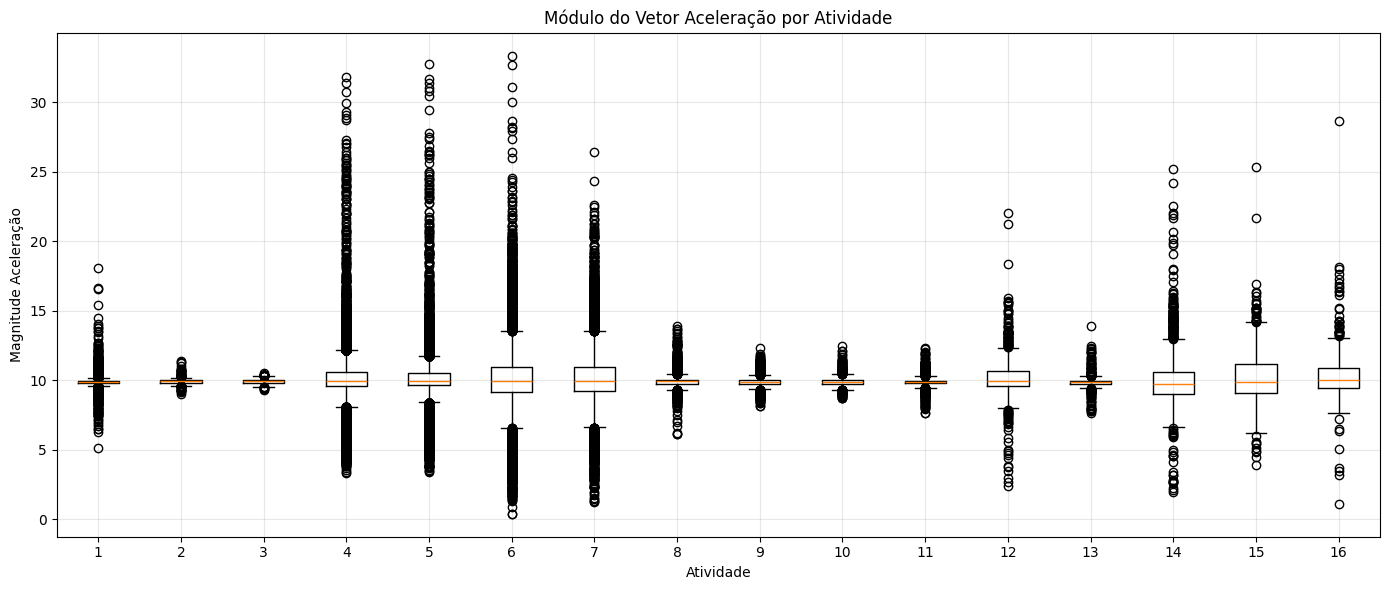

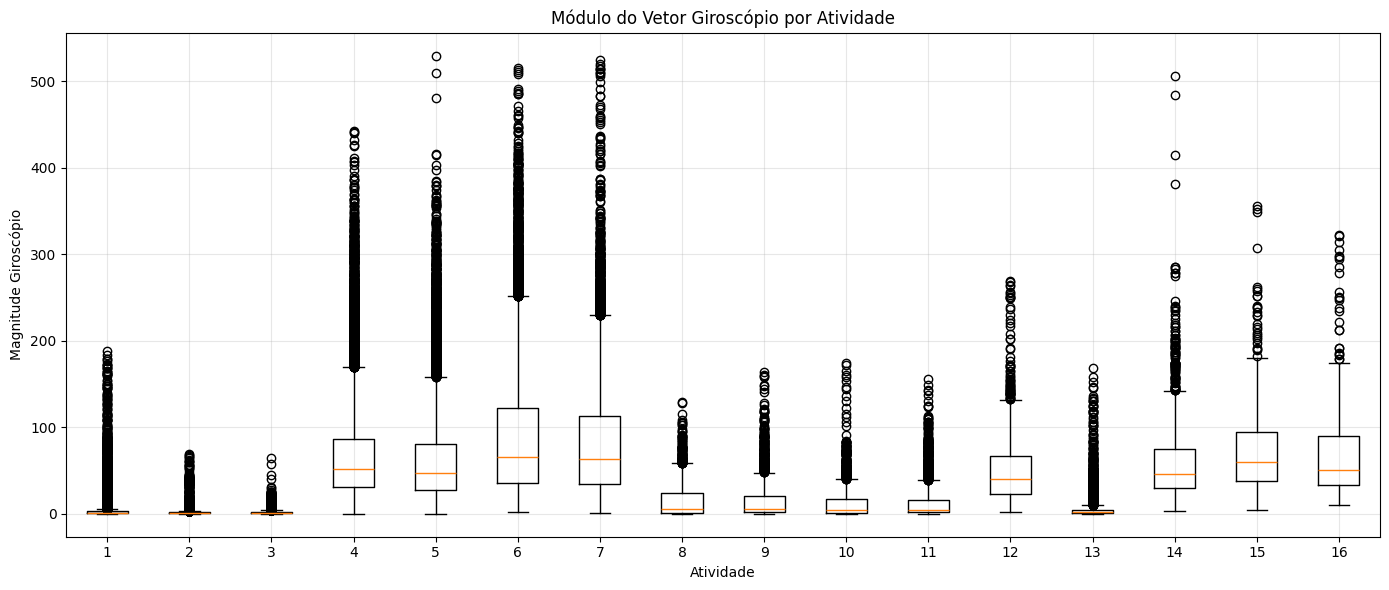

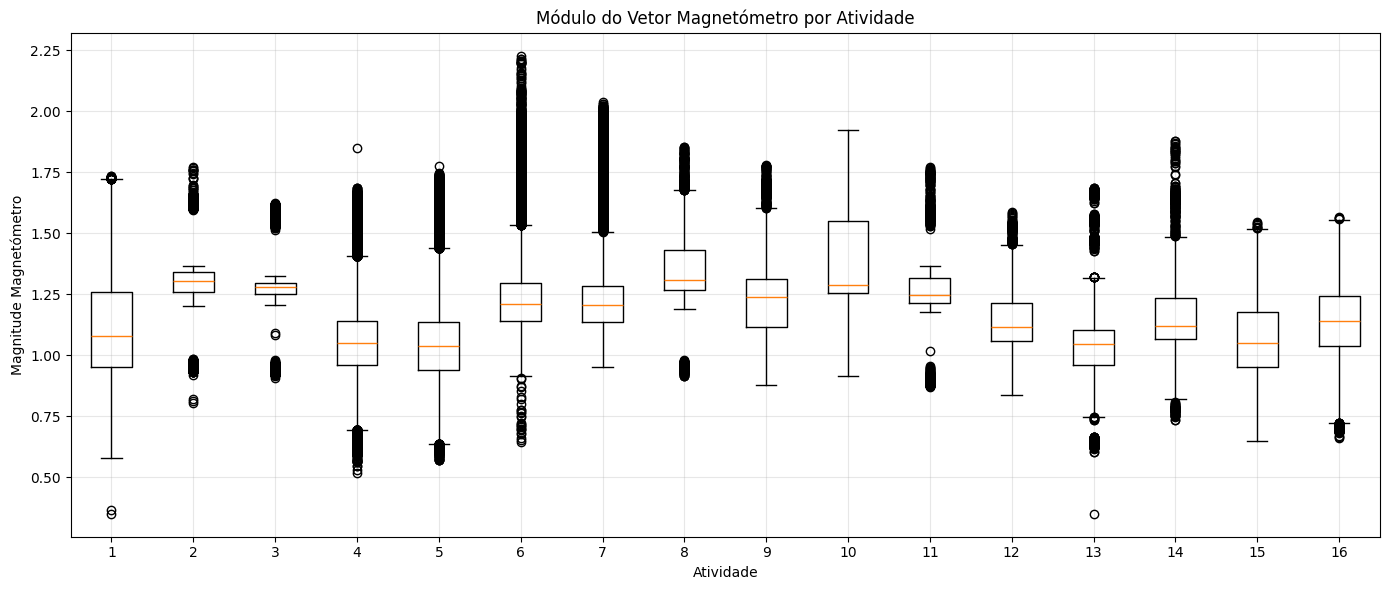

In [3]:

def calculate_vector_magnitude(data_array, start_col):
    x = data_array[:, start_col]
    y = data_array[:, start_col + 1]
    z = data_array[:, start_col + 2]

    magnitude = np.sqrt(x ** 2 + y ** 2 + z ** 2)

    return magnitude

def plot_boxplot_by_activity(data_array, vector_type='accel'):
    # Definir coluna inicial baseada no tipo de vetor
    if vector_type == 'accel':
        start_col = 1
        title = 'Módulo do Vetor Aceleração por Atividade'
        ylabel = 'Magnitude Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title = 'Módulo do Vetor Giroscópio por Atividade'
        ylabel = 'Magnitude Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title = 'Módulo do Vetor Magnetómetro por Atividade'
        ylabel = 'Magnitude Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular o módulo do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Obter as atividades
    activities = data_array[:, 11]

    # Obter atividades únicas e ordenar
    unique_activities = np.sort(np.unique(activities))

    # Preparar dados para o boxplot
    data_by_activity = []
    for activity in unique_activities:
        mask = activities == activity
        data_by_activity.append(magnitude[mask])

    # Criar o boxplot
    plt.figure(figsize=(14, 6))
    plt.boxplot(data_by_activity, tick_labels=unique_activities.astype(int))
    plt.xlabel('Atividade')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show(block=False)

for v in ['accel', 'gyro', 'mag']:
    plot_boxplot_by_activity( data, vector_type=v)

## 3.2 Densidade de outliers (IQR – Tukey)

A função 'calcular_densidade_outliers' implementa a deteção de outliers com base no método IQR (Interquartile Range), usando especificamente o dispositivo do pulso direito (device ID = 2). Para cada atividade, são calculados os limites inferior e superior (Q1 - 1.5*IQR e Q3 + 1.5*IQR). Os pontos fora deste intervalo são classificados como outliers e a densidade é dada por d = (no/nr)*100, sendo ‘no’ o número de outliers e ‘nr’ o número total de amostras. Este método permite avaliar a robustez dos sensores e a variabilidade das atividades.

In [4]:
def calcular_densidade_outliers(data_array, vector_type='accel', k=3):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Escolher o dispositivo (pulso direito)
    mask_device = data_array[:, 0] == 2
    data_filtered = data_array[mask_device]

    magnitude = calculate_vector_magnitude(data_filtered, start_col)
    activities = data_filtered[:, 11]
    unique_activities = np.sort(np.unique(activities))

    densidades = {}
    for activity in unique_activities:
        mask = activities == activity
        dados_atividade = magnitude[mask]

        # --- Método IQR (Tukey) ---
        Q1 = np.percentile(dados_atividade, 25)
        Q3 = np.percentile(dados_atividade, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dados_atividade[(dados_atividade < lower_bound) | (dados_atividade > upper_bound)]

        no = len(outliers)
        nr = len(dados_atividade)
        densidade = (no / nr) * 100 if nr > 0 else 0
        densidades[int(activity)] = densidade

    print(f"\nDensidades de outliers ({vector_type},):")
    for a, d in densidades.items():
        print(f"  Atividade {a}: {d:.2f}%")

    return densidades


for v in ['accel', 'gyro', 'mag']:
    calcular_densidade_outliers (data, vector_type=v, k=3)


Densidades de outliers (accel,):
  Atividade 1: 3.43%
  Atividade 2: 3.98%
  Atividade 3: 4.05%
  Atividade 4: 1.68%
  Atividade 5: 2.36%
  Atividade 6: 4.47%
  Atividade 7: 2.41%
  Atividade 8: 24.61%
  Atividade 9: 23.70%
  Atividade 10: 24.22%
  Atividade 11: 18.49%
  Atividade 12: 3.15%
  Atividade 13: 0.79%
  Atividade 14: 11.02%
  Atividade 15: 2.36%
  Atividade 16: 1.57%

Densidades de outliers (gyro,):
  Atividade 1: 6.82%
  Atividade 2: 5.34%
  Atividade 3: 8.59%
  Atividade 4: 1.85%
  Atividade 5: 1.46%
  Atividade 6: 1.20%
  Atividade 7: 3.12%
  Atividade 8: 3.52%
  Atividade 9: 2.08%
  Atividade 10: 7.62%
  Atividade 11: 11.20%
  Atividade 12: 3.54%
  Atividade 13: 1.18%
  Atividade 14: 8.66%
  Atividade 15: 10.24%
  Atividade 16: 12.60%

Densidades de outliers (mag,):
  Atividade 1: 0.00%
  Atividade 2: 2.11%
  Atividade 3: 0.05%
  Atividade 4: 0.14%
  Atividade 5: 0.00%
  Atividade 6: 0.00%
  Atividade 7: 0.00%
  Atividade 8: 4.88%
  Atividade 9: 13.02%
  Atividade 10: 1

## 3.3 Deteção de outliers por Z-score

Foi implementada a função 'detectar_outliers_zscore', que identifica valores fora de um intervalo definido pela média ± k vezes o desvio padrão. O parâmetro k é ajustável, sendo usados os valores 3, 3.5 e 4. Primeiro os dados são convertidos para um array NumPy, e depois são calculados a média e o desvio padrão, dois valores da formula do Z-score. Se o desvio padrão for igual a 0, o cálculo do Z-score torna-se impossível (divisão por zero). 
O Z-score é útil para dados com distribuição aproximadamente normal, permitindo identificar pontos muito afastados da média.


In [5]:
def detectar_outliers_zscore(dados, k=3):
    # Converter para array NumPy
    dados = np.array(dados)

    # Calcular média e desvio padrão
    media = np.mean(dados)
    desvio = np.std(dados)

    # Evitar divisão por zero
    if desvio == 0:
        return np.array([]), np.array([])

    # Calcular Z-scores
    z_scores = (dados - media) / desvio

    # Identificar outliers
    mask_outliers = np.abs(z_scores) > k

    return dados[mask_outliers], np.where(mask_outliers)[0]



## 3.4 Visualização de outliers (Z-score)

A função 'plot_outliers_zscore' utiliza o método anterior para destacar, graficamente, os pontos considerados outliers em vermelho e os pontos normais em azul. Os resultados evidenciam que, para k mais baixos, há uma maior deteção de outliers, enquanto valores mais altos tornam o critério mais permissivo.

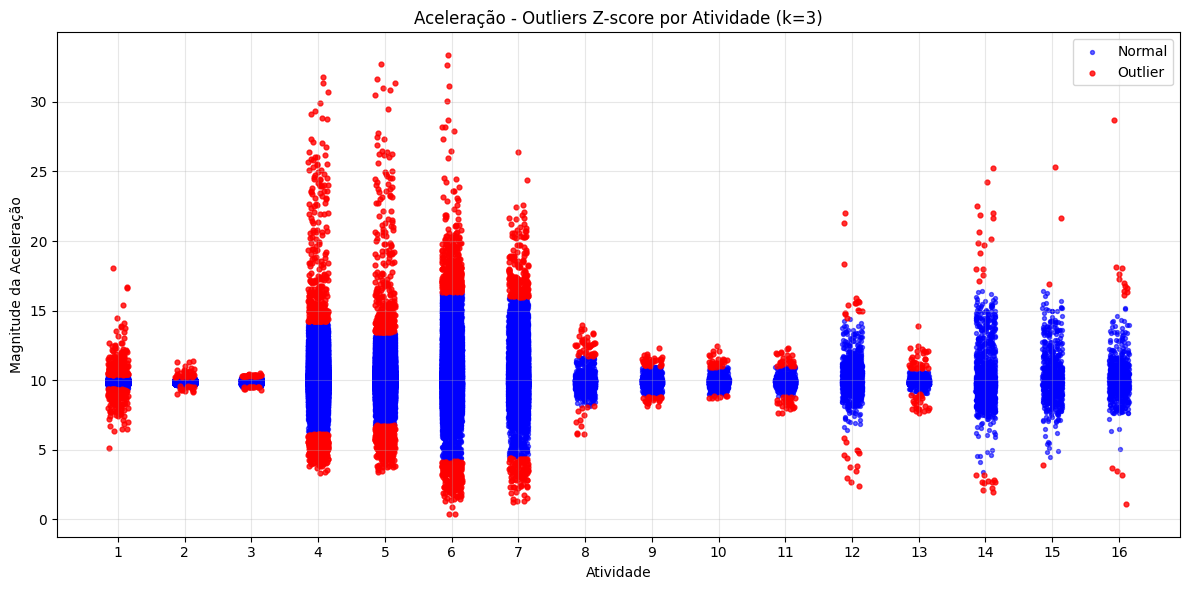

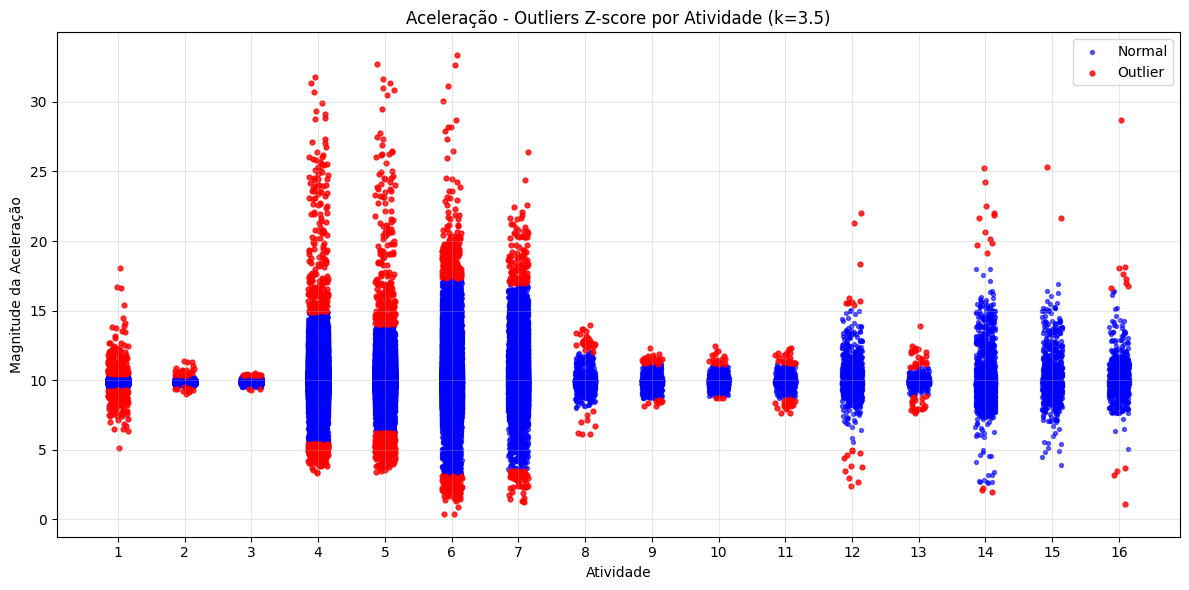

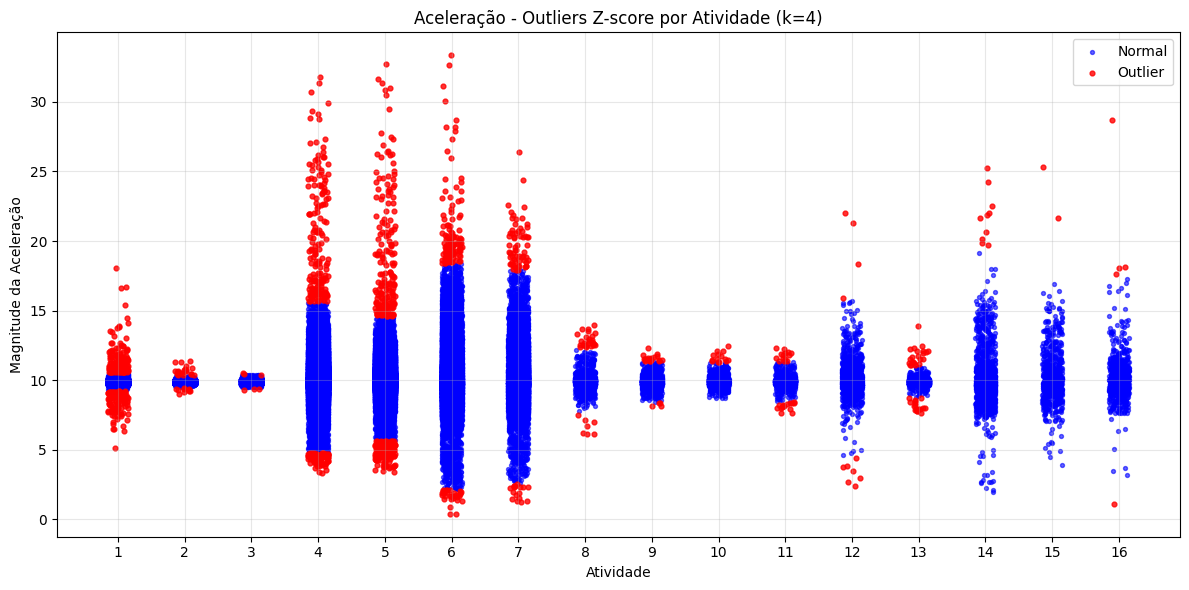

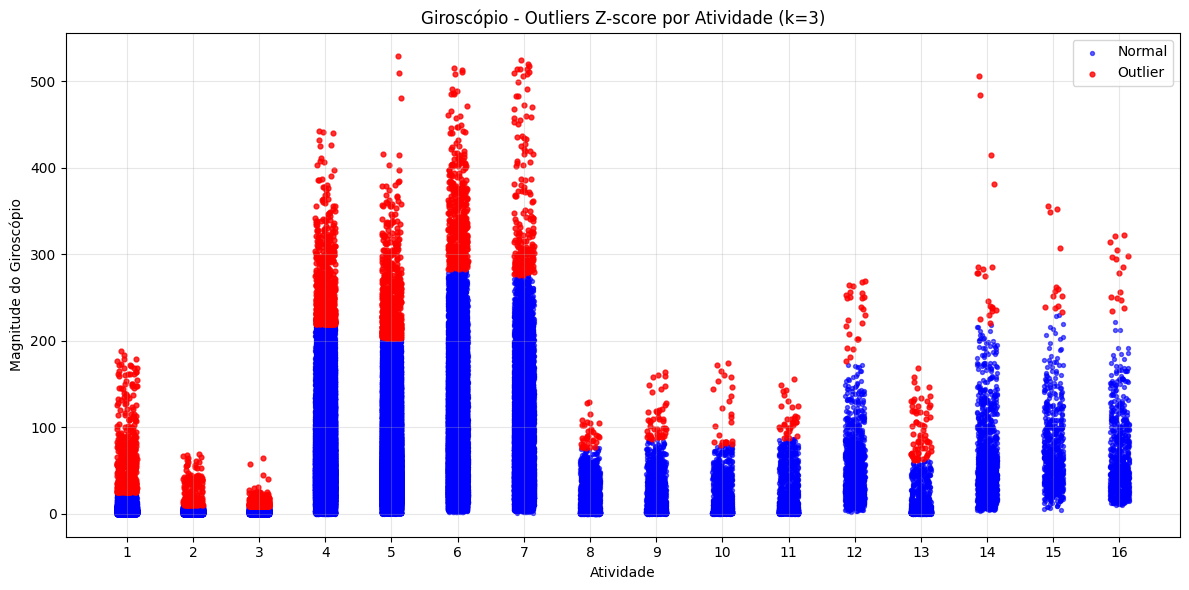

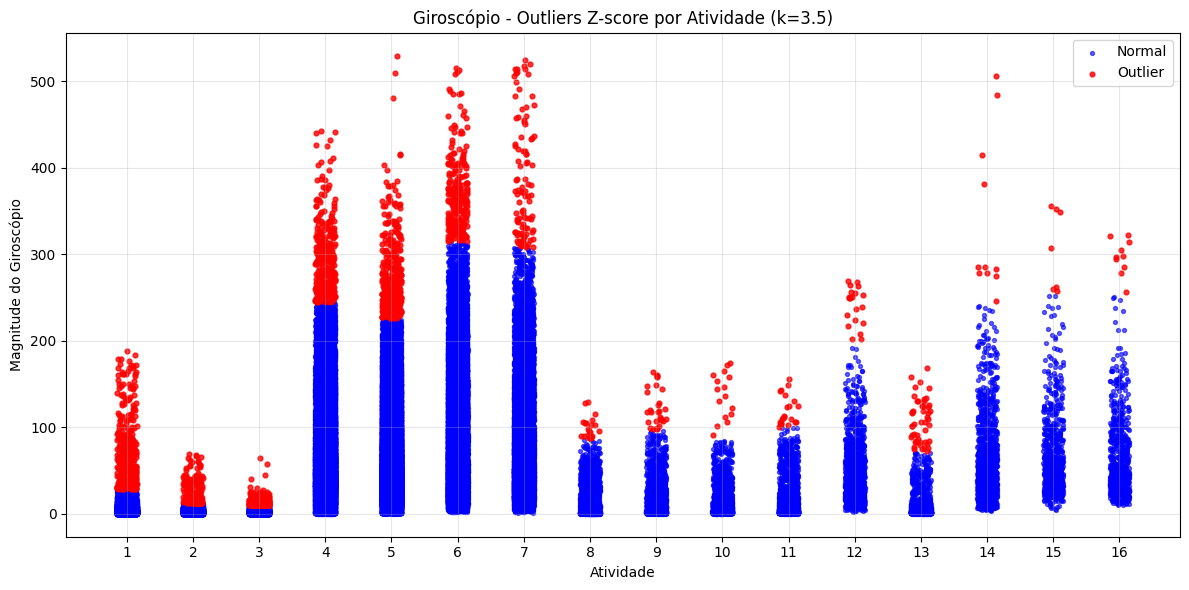

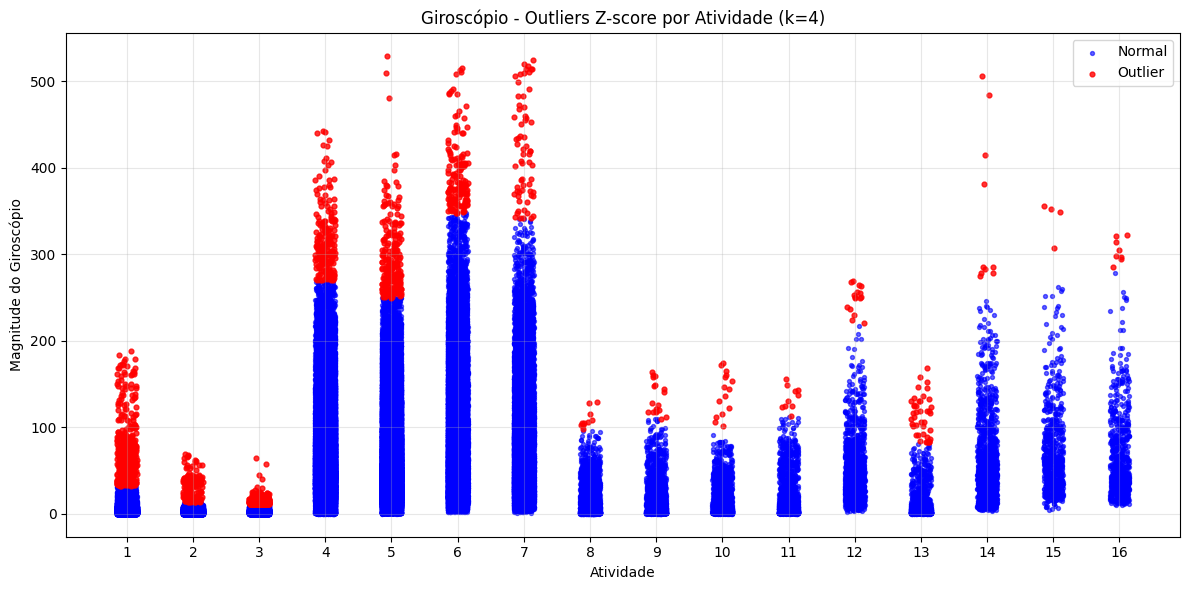

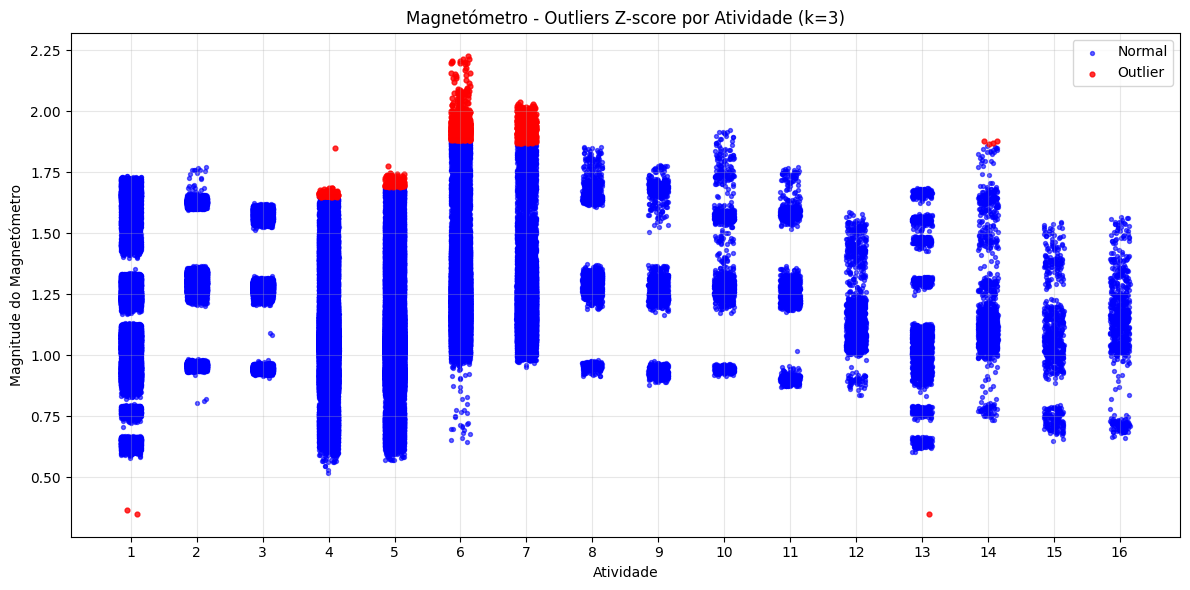

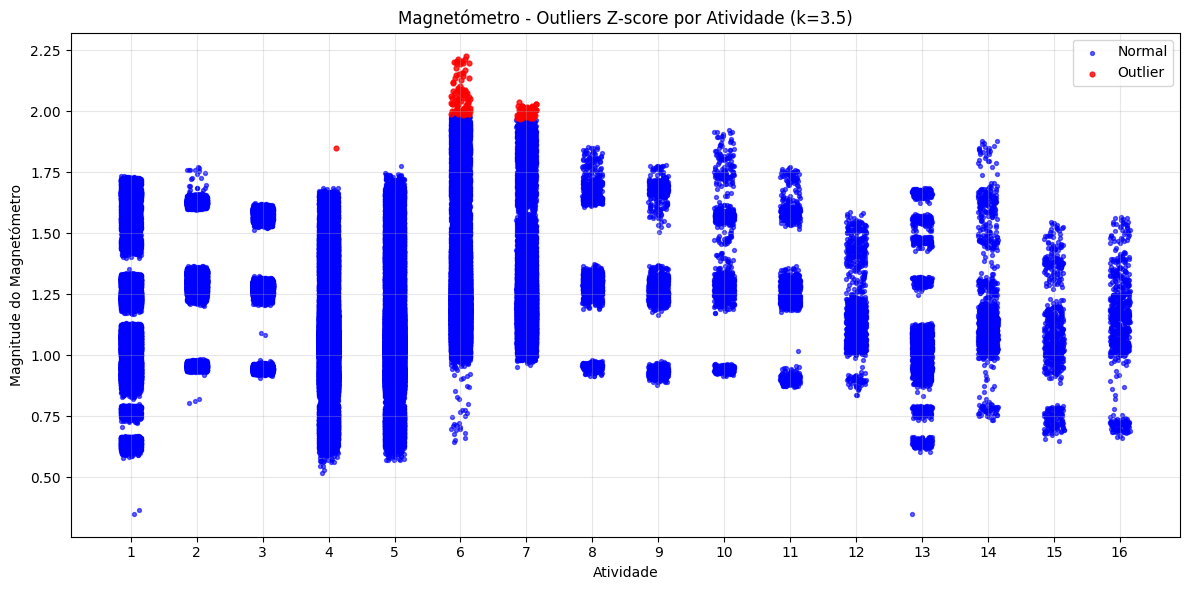

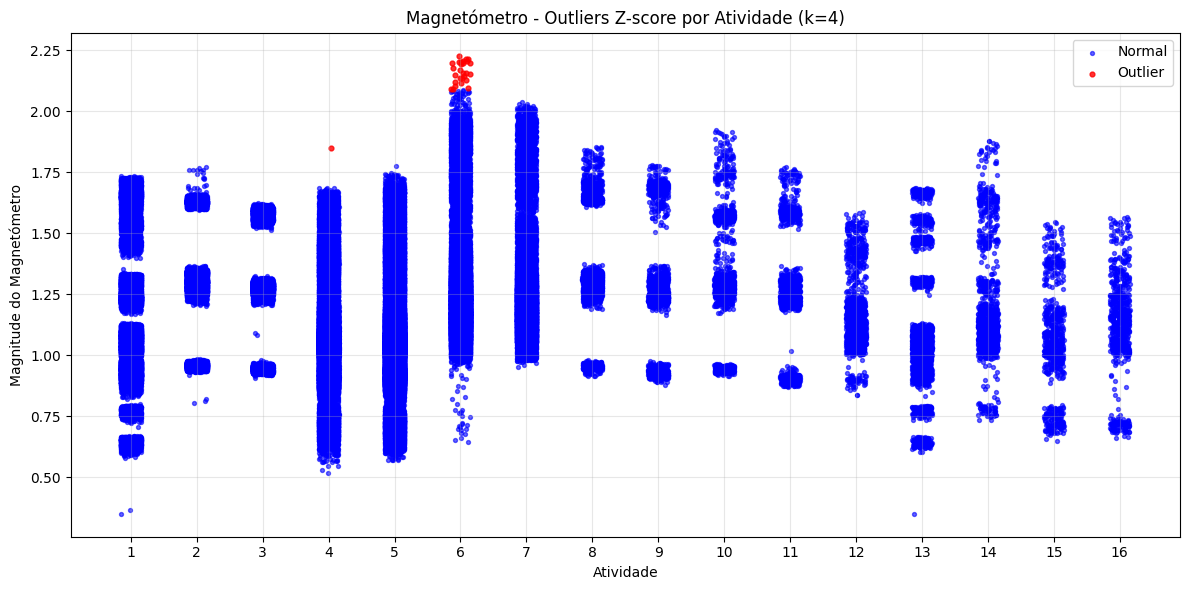

In [6]:
def plot_outliers_zscore(data_array, vector_type='accel', k_values=[3]):

    # Definir coluna inicial e rótulos
    if vector_type == 'accel':
        start_col = 1
        title_base = 'Aceleração'
        ylabel = 'Magnitude da Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title_base = 'Giroscópio'
        ylabel = 'Magnitude do Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title_base = 'Magnetómetro'
        ylabel = 'Magnitude do Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))

    # Criar um gráfico para cada valor de k
    for k in k_values:
        plt.figure(figsize=(12, 6))

        for idx, activity in enumerate(unique_activities):
            mask = activities == activity
            dados_atividade = magnitude[mask]

            # Calcular Z-score por atividade
            media = np.mean(dados_atividade)
            desvio = np.std(dados_atividade)
            if desvio == 0:
                z_scores = np.zeros_like(dados_atividade)
            else:
                z_scores = (dados_atividade - media) / desvio

            # Detectar outliers
            mask_outliers = np.abs(z_scores) > k

            # Adicionar leve jitter no eixo X para visualização
            jitter = np.random.uniform(-0.15, 0.15, size=len(dados_atividade))
            x_vals = np.full_like(dados_atividade, fill_value=activity, dtype=float) + jitter

            # Plotar pontos normais e outliers
            plt.scatter(x_vals[~mask_outliers], dados_atividade[~mask_outliers],
                        color='blue', s=8, alpha=0.6, label='Normal' if idx == 0 else "")
            plt.scatter(x_vals[mask_outliers], dados_atividade[mask_outliers],
                        color='red', s=12, alpha=0.8, label='Outlier' if idx == 0 else "")

        plt.title(f"{title_base} - Outliers Z-score por Atividade (k={k})")
        plt.xlabel("Atividade")
        plt.ylabel(ylabel)
        plt.xticks(unique_activities.astype(int))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show(block=False)


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_zscore (data, vector_type=v, k_values=[3, 3.5, 4])



## 3.5 Comparação entre IQR vs Z-score

Comparando os métodos, o IQR é mais robusto a distribuições não normais, enquanto o Z-score é sensível a valores extremos e assume simetria. No dataset, observou-se que ambos identificam padrões semelhantes, embora o Z-score tenda a detectar ligeiramente mais outliers em atividades de maior movimento, como 'Walk' e 'Run'.

## 3.6 Implementação do algoritmo K-means

Foi implementado o algoritmo K-means do zero ('k_means'), usando operações vetorizadas do NumPy para ganhar eficiência. O método inicializa centróides aleatoriamente, calcula as distâncias euclidianas entre pontos e centroids de modo a que pontos dentro de cada cluster sejam semelhantes entre si e diferentes dos outros clusters, e atualiza iterativamente até à convergência.

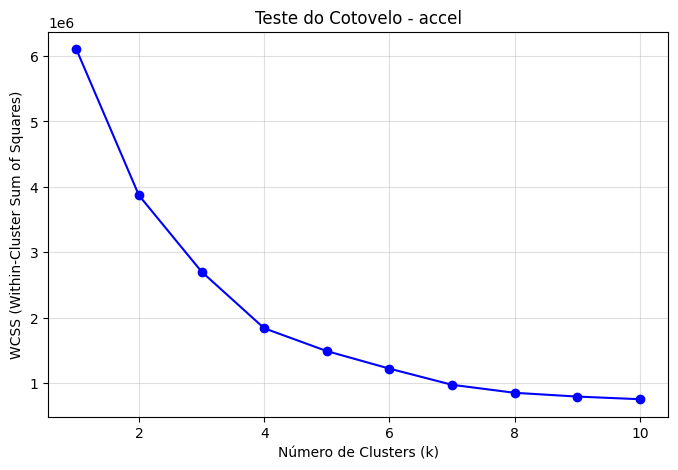

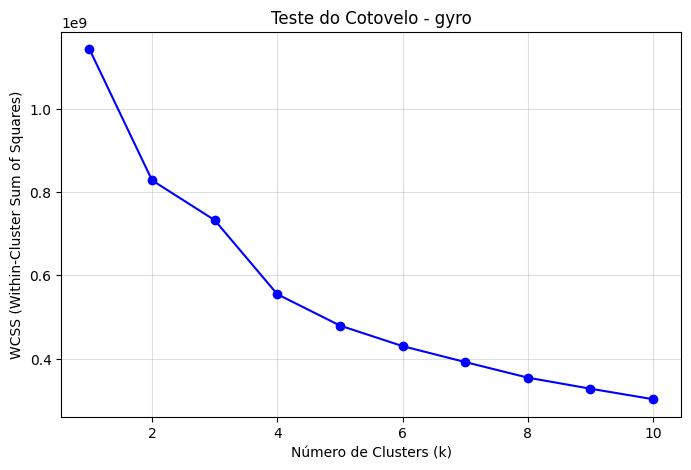

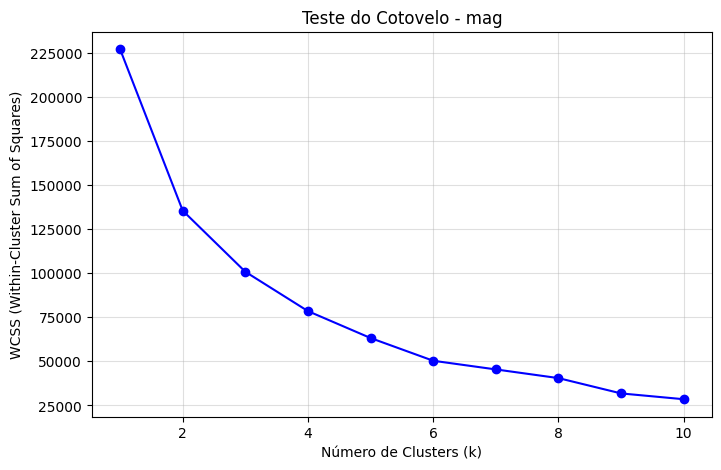


  A executar K-means para accel...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  A executar K-means para gyro...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  A executar K-means para mag...
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.
 Execução do 3.6 concluída!


In [7]:

def k_means(data, n_clusters, max_iters=100, tol=1e-3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = data.shape[0]

    # Inicializar centróides aleatoriamente
    indices = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = data[indices].copy()

    for iteration in range(max_iters):
        # Calcular distâncias (vectorizado)
        distances = np.linalg.norm(data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # Recalcular centróides
        centroids_old = centroids.copy()
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)
            else:
                centroids[k] = data[np.random.choice(n_samples)]

        # Verificar convergência
        if np.linalg.norm(centroids - centroids_old) < tol:
            break

    return labels, centroids

def elbow_method(data_array, vector_type='accel', max_k=10):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    data_3d = data_array[:, start_col:start_col + 3]
    wcss = []

    for k in range(1, max_k + 1):
        labels, centroids = k_means(data_3d, k, random_state=42)
        distances = np.linalg.norm(data_3d - centroids[labels], axis=1)
        wcss.append(np.sum(distances ** 2))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss, 'bo-', markersize=6)
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.title(f'Teste do Cotovelo - {vector_type}')
    plt.grid(True, alpha=0.4)
    plt.show(block=False)

    return wcss

for v in ['accel', 'gyro', 'mag']:
    elbow_method (data, vector_type=v, max_k=10)
    
for v in ['accel', 'gyro', 'mag']:
    print(f"\n  A executar K-means para {v}...")
    data_3d = data[:, {'accel': 1, 'gyro': 4, 'mag': 7}[v]:{'accel': 1, 'gyro': 4, 'mag': 7}[v] + 3]
    for n_clusters in [2, 3, 4, 5, 6, 7, 8]:
        _, centroids = k_means(data_3d, n_clusters, random_state=42)
        print(f" - K={n_clusters}: {len(centroids)} centróides calculados.")
print(" Execução do 3.6 concluída!")

## 3.7 Deteção de outliers com K-means

A função 'detectar_outliers_kmeans' aplica o K-means no espaço tridimensional (x, y, z) para aceleração, giroscópio e magnetómetro. Os pontos pertencentes aos clusters com menos de 3% dos dados são considerados outliers. A densidade de outliers é calculada e os resultados mostram coerência com os métodos anteriores. Foi também criada a função 'plot_outliers_kmeans_3d' para visualização 3D (não usada neste relatório textual).
Além disso, a função 'comparar_kmeans_vs_zscore' compara quantitativamente os resultados dos dois métodos, mostrando o número de outliers detetados por cada abordagem e o grau de concordância entre ambos, sendo que apenas no giroscópio existe alguma concordância.



K-means com 3 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(26718), np.int64(1): np.int64(83815), np.int64(2): np.int64(155707)}


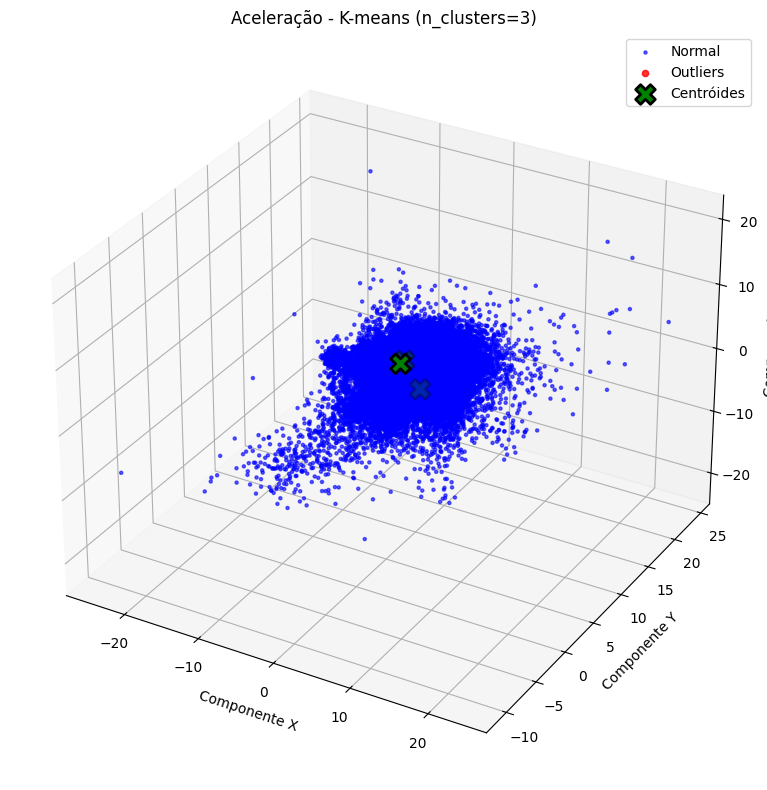


K-means com 5 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(56474), np.int64(1): np.int64(74529), np.int64(2): np.int64(13124), np.int64(3): np.int64(96499), np.int64(4): np.int64(25614)}


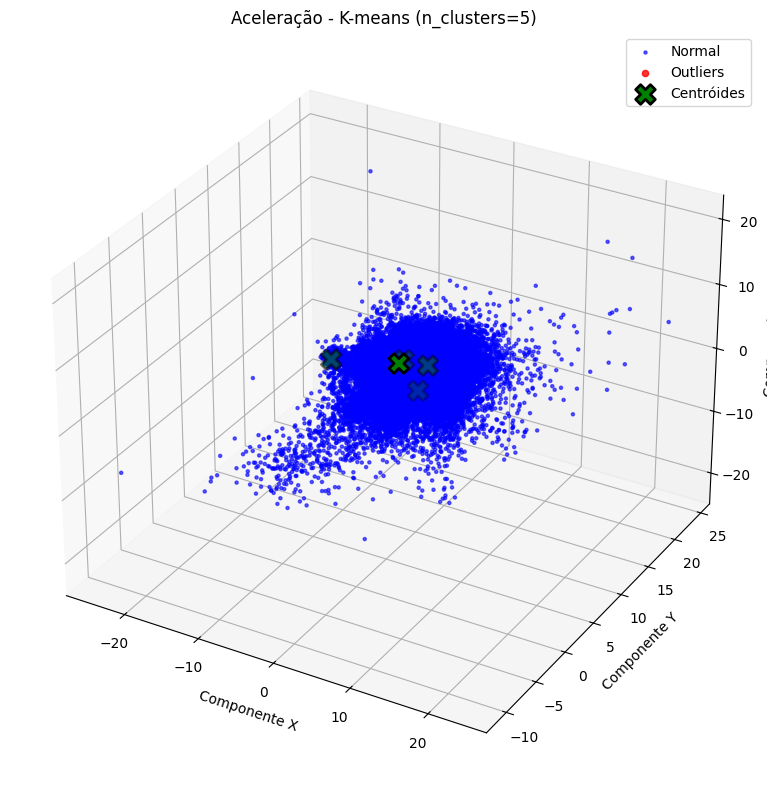


K-means com 6 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(15010), np.int64(1): np.int64(76926), np.int64(2): np.int64(12882), np.int64(3): np.int64(99725), np.int64(4): np.int64(12972), np.int64(5): np.int64(48725)}


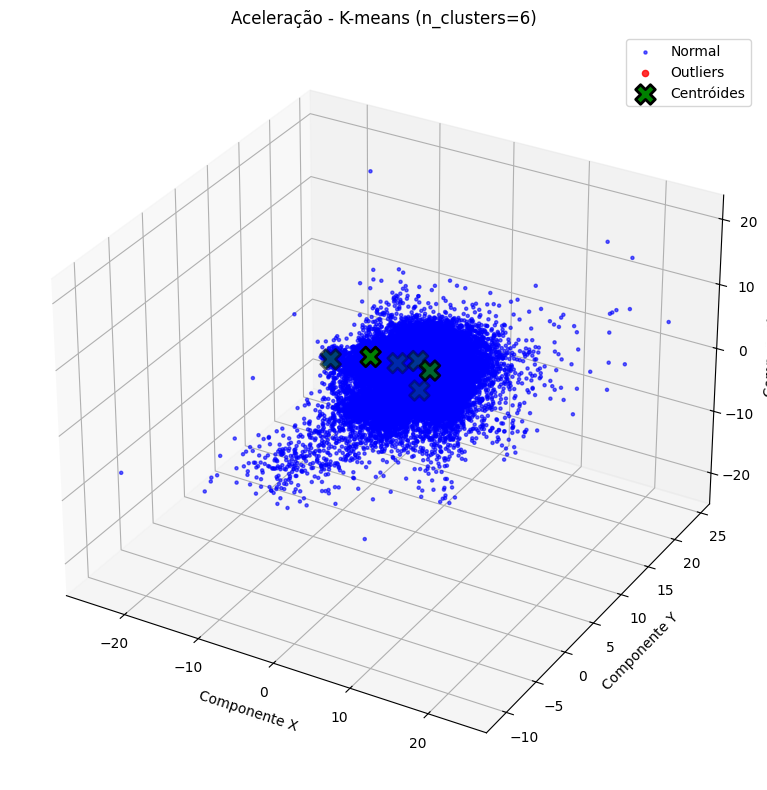


K-means com 3 clusters (gyro):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(13607), np.int64(1): np.int64(201202), np.int64(2): np.int64(51431)}


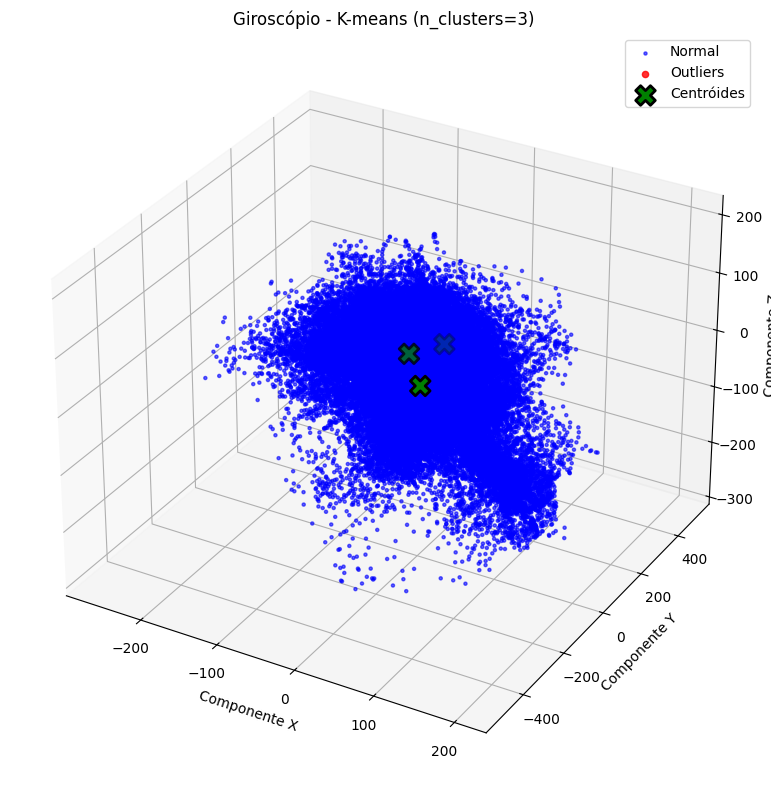


K-means com 5 clusters (gyro):
  Outliers detectados: 5935/266240 (2.23%)
  Distribuição por cluster: {np.int64(0): np.int64(12467), np.int64(1): np.int64(11024), np.int64(2): np.int64(37986), np.int64(3): np.int64(5935), np.int64(4): np.int64(198828)}


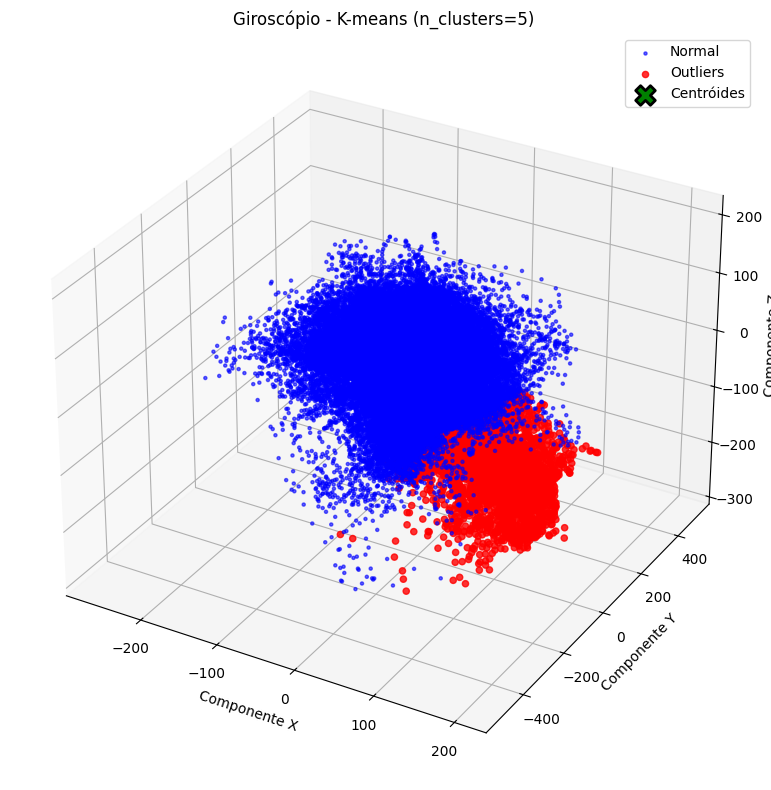


K-means com 6 clusters (gyro):
  Outliers detectados: 6085/266240 (2.29%)
  Distribuição por cluster: {np.int64(0): np.int64(35494), np.int64(1): np.int64(10466), np.int64(2): np.int64(11174), np.int64(3): np.int64(6085), np.int64(4): np.int64(193994), np.int64(5): np.int64(9027)}


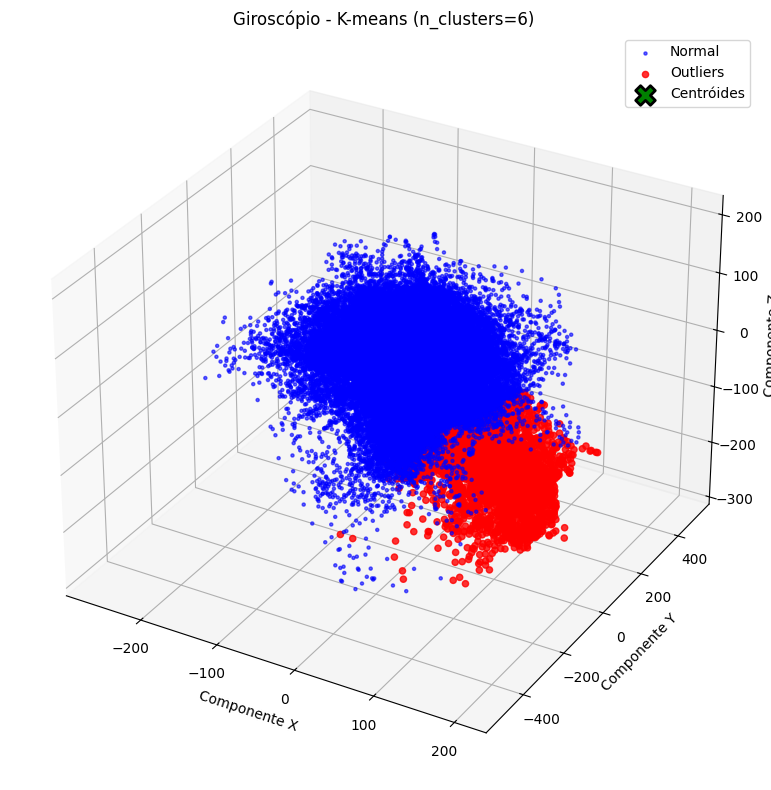


K-means com 3 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(110695), np.int64(1): np.int64(80756), np.int64(2): np.int64(74789)}


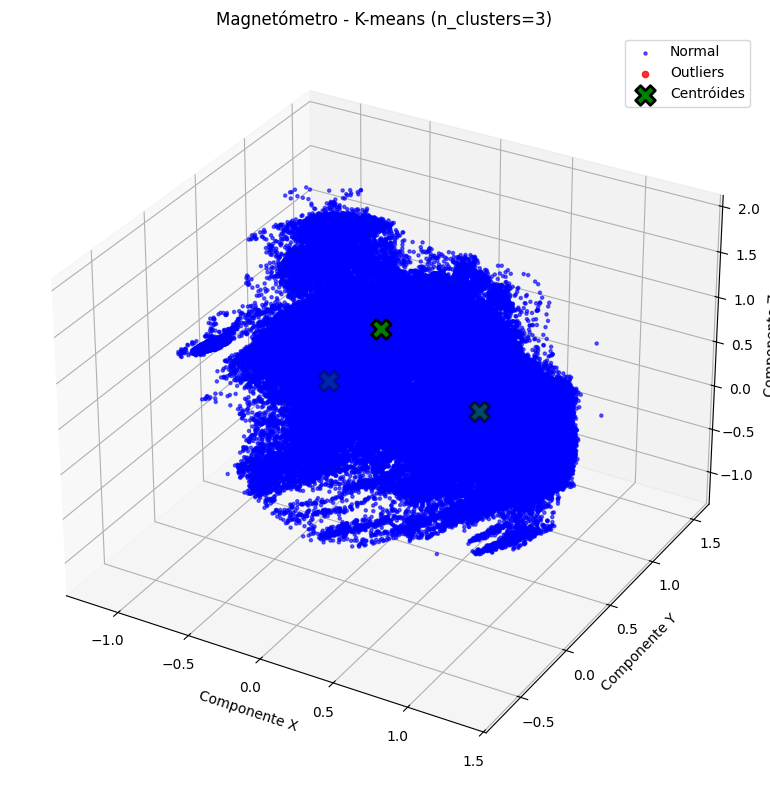


K-means com 5 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(79944), np.int64(1): np.int64(50323), np.int64(2): np.int64(56693), np.int64(3): np.int64(48880), np.int64(4): np.int64(30400)}


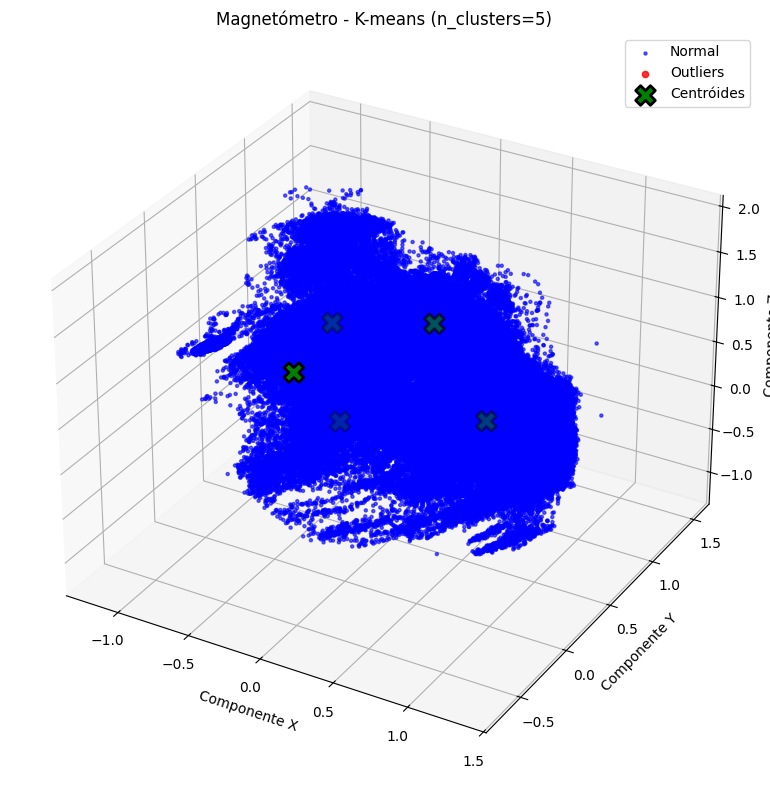


K-means com 6 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(46679), np.int64(1): np.int64(53458), np.int64(2): np.int64(32872), np.int64(3): np.int64(60582), np.int64(4): np.int64(24490), np.int64(5): np.int64(48159)}


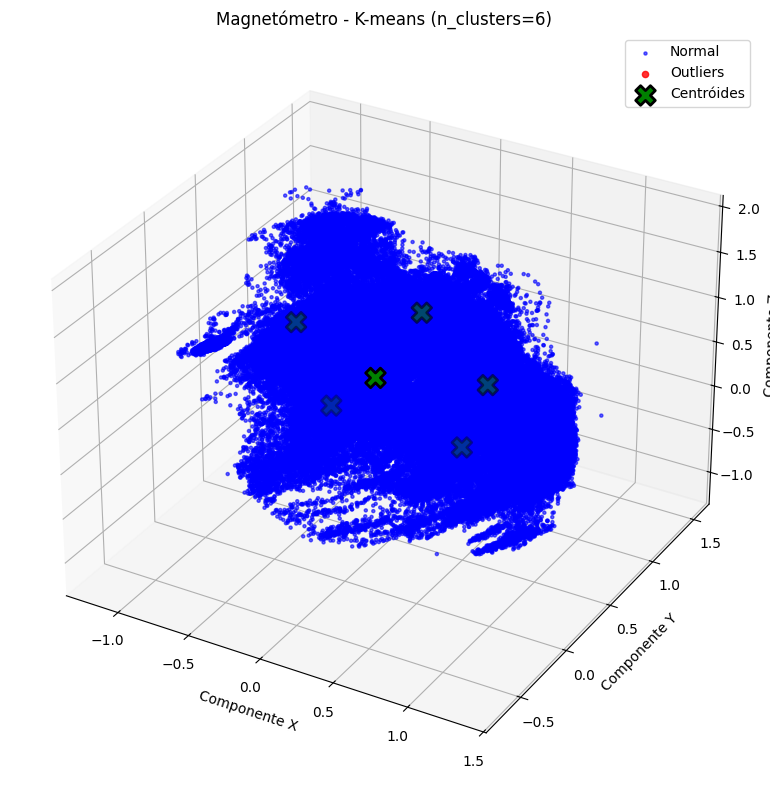

In [8]:
def detectar_outliers_kmeans(data_array, vector_type='accel', n_clusters=4):
    """
    3.7 - Determina outliers usando K-means.
    Pontos em clusters muito pequenos são considerados outliers.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor: 'accel', 'gyro' ou 'mag'
    n_clusters : int
        Número de clusters

    Retorna:
    --------
    outlier_mask : numpy.ndarray
        Máscara booleana indicando outliers
    labels : numpy.ndarray
        Etiquetas de cluster
    """

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Extrair os 3 componentes do vetor
    data_3d = data_array[:, start_col:start_col + 3]

    # Aplicar K-means
    labels, centroids = k_means(data_3d, n_clusters, random_state=42)

    # Contar pontos em cada cluster
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Clusters com menos de 3% dos dados são outliers
    threshold = len(data_3d) * 0.03
    outlier_clusters = unique_labels[counts < threshold]

    # Criar máscara de outliers
    outlier_mask = np.isin(labels, outlier_clusters)

    n_outliers = np.sum(outlier_mask)
    density = (n_outliers / len(data_3d)) * 100

    print(f"\nK-means com {n_clusters} clusters ({vector_type}):")
    print(f"  Outliers detectados: {n_outliers}/{len(data_3d)} ({density:.2f}%)")
    print(f"  Distribuição por cluster: {dict(zip(unique_labels, counts))}")

    return outlier_mask, labels, data_3d, centroids

def plot_outliers_kmeans_3d(data_array, vector_type='accel', n_clusters_list=[3, 4, 5, 6]):
    """
    3.7 - Visualiza outliers detectados por K-means em gráficos 3D.
    Compara diferentes números de clusters.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor
    n_clusters_list : list
        Lista de números de clusters a testar
    """

    if vector_type == 'accel':
        title_base = 'Aceleração'
    elif vector_type == 'gyro':
        title_base = 'Giroscópio'
    elif vector_type == 'mag':
        title_base = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    for n_clusters in n_clusters_list:
        outlier_mask, labels, data_3d, centroids = detectar_outliers_kmeans(
            data_array, vector_type, n_clusters
        )

        # Criar figura 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plotar pontos normais (azul)
        normal_points = data_3d[~outlier_mask]
        ax.scatter(normal_points[:, 0], normal_points[:, 1], normal_points[:, 2],
                   c='blue', s=5, alpha=0.6, label='Normal')

        # Plotar outliers (vermelho)
        outlier_points = data_3d[outlier_mask]
        ax.scatter(outlier_points[:, 0], outlier_points[:, 1], outlier_points[:, 2],
                   c='red', s=20, alpha=0.8, label='Outliers')

        # Plotar centros dos clusters (verde)
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='green', marker='X', s=200, label='Centróides', edgecolors='black', linewidths=2)

        ax.set_xlabel('Componente X')
        ax.set_ylabel('Componente Y')
        ax.set_zlabel('Componente Z')
        ax.set_title(f'{title_base} - K-means (n_clusters={n_clusters})')
        ax.legend()

        plt.tight_layout()
        plt.show(block=False)

def comparar_kmeans_vs_zscore(data_array, vector_type='accel', n_clusters=5, k=3):
    """
    3.7 - Compara resultados do K-means com Z-score.

    Parâmetros:
    -----------
    data_array : numpy.ndarray
        Array com todos os dados
    vector_type : str
        Tipo de vetor
    n_clusters : int
        Número de clusters para K-means
    k : float
        Parâmetro k para Z-score
    """

    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Outliers K-means
    outlier_mask_kmeans, _, _, _ = detectar_outliers_kmeans(data_array, vector_type, n_clusters)

    # Outliers Z-score
    media = np.mean(magnitude)
    desvio = np.std(magnitude)
    if desvio > 0:
        z_scores = (magnitude - media) / desvio
        outlier_mask_zscore = np.abs(z_scores) > k
    else:
        outlier_mask_zscore = np.zeros(len(magnitude), dtype=bool)

    # Estatísticas
    n_kmeans = np.sum(outlier_mask_kmeans)
    n_zscore = np.sum(outlier_mask_zscore)
    both = np.sum(outlier_mask_kmeans & outlier_mask_zscore)

    print(f"\n{'=' * 80}")
    print(f"COMPARAÇÃO: K-means vs Z-score ({label})")
    print(f"{'=' * 80}")
    print(f"Outliers K-means (n_clusters={n_clusters}): {n_kmeans} ({n_kmeans / len(magnitude) * 100:.2f}%)")
    print(f"Outliers Z-score (k={k}): {n_zscore} ({n_zscore / len(magnitude) * 100:.2f}%)")
    print(f"Outliers detectados por ambos: {both}")
    print(f"Concordância: {both / max(n_kmeans, n_zscore) * 100:.2f}% (dos detectados por K-means)")
    print(f"{'=' * 80}\n")

    return outlier_mask_kmeans, outlier_mask_zscore


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_kmeans_3d (data, vector_type=v, n_clusters_list=[3, 5, 6])


# 4. Extração e Seleção de Características

## 4.1 Testes de significância

A função 'determinar_significancia_atividade' verifica a normalidade das distribuições de cada atividade com o teste de Kolmogorov–Smirnov. Dependendo do resultado, aplica-se o teste ANOVA (para dados normais) ou Kruskal-Wallis (não paramétrico) para avaliar se há diferenças estatisticamente significativas entre as médias das atividades. Os resultados permitem concluir que as magnitudes variam significativamente entre atividades.

In [9]:
def determinar_significancia_atividade(data_array, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))
    grupos = [magnitude[activities == a] for a in unique_activities]

    normalidades = []
    for g in grupos:
        if len(g) > 0:
            std_g = np.std(g)
            if std_g == 0:
                normalidades.append(False)
            else:
                stat, p_val = kstest((g - np.mean(g)) / std_g, 'norm')
                normalidades.append(p_val > 0.05)
        else:
            normalidades.append(False)

    normal = all(normalidades)
    if normal:
        stat, p_value = f_oneway(*grupos)
        teste_usado = 'ANOVA (paramétrico)'
    else:
        stat, p_value = kruskal(*grupos)
        teste_usado = 'Kruskal-Wallis (não paramétrico)'

    print(f"\n{'=' * 80}")
    print(f"4.1 - Teste de significância ({label})")
    print(f"{'-' * 80}")
    print(f"Normalidade (todas as atividades normais?): {'Sim' if normal else 'Não'}")
    print(f"Teste usado: {teste_usado}")
    print(f"Estatística = {stat:.4f}, p-valor = {p_value:.6f}")
    print(f"{'=' * 80}\n")
    return {'vector': vector_type, 'teste': teste_usado, 'p_value': p_value, 'normal': normal}

for v in ['accel', 'gyro', 'mag']:
    determinar_significancia_atividade (data, vector_type=v)



4.1 - Teste de significância (Aceleração)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 2649.1260, p-valor = 0.000000


4.1 - Teste de significância (Giroscópio)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 189647.6025, p-valor = 0.000000


4.1 - Teste de significância (Magnetómetro)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 50804.4657, p-valor = 0.000000



## 4.2 Extração de features temporais e espectrais

As rotinas 'extract_temporal_features' e 'extract_spectral_features' calculam, respetivamente, as estatísticas temporais (média, desvio padrão, máximo, mínimo, energia) e as espectrais (potência média e frequência dominante) para cada eixo. Os dados são segmentados em janelas de 5 segundos com 50% de sobreposição ('sliding_window_segments'). Apenas segmentos com uma única atividade são considerados.

In [10]:
def sliding_window_segments(data_array, window_size_sec=5, overlap=0.5, fs=50):
    window_size = int(window_size_sec * fs)
    step_size = int(window_size * (1 - overlap))
    activities = data_array[:, 11]
    segments = []
    for start in range(0, len(data_array) - window_size + 1, step_size):
        end = start + window_size
        window = data_array[start:end]
        if len(np.unique(window[:, 11])) == 1:
            segments.append(window)
    return segments

def extract_temporal_features(segment, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        features.extend([np.mean(axis_data), np.std(axis_data),
                         np.max(axis_data), np.min(axis_data),
                         np.sum(axis_data ** 2) / len(axis_data)])
    return np.array(features)

def extract_spectral_features(segment, vector_type='accel', fs=50):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        freqs, psd = welch(axis_data, fs=fs, nperseg=min(256, len(axis_data)))
        features.extend([np.mean(psd), freqs[np.argmax(psd)]])
    return np.array(features)

def extract_feature_vector(segment, vector_type='accel', fs=50):
    return np.concatenate([extract_temporal_features(segment, vector_type),
                           extract_spectral_features(segment, vector_type, fs)])

def extract_feature_set(data_array, vector_type='accel', window_size_sec=5, overlap=0.5, fs=50):
    segments = sliding_window_segments(data_array, window_size_sec, overlap, fs)
    X, y = [], []
    for segment in segments:
        X.append(extract_feature_vector(segment, vector_type, fs))
        y.append(int(segment[0, 11]))
    return np.array(X), np.array(y)


X_accel, y_accel = extract_feature_set(data, vector_type='accel')
X_gyro, y_gyro = extract_feature_set(data, vector_type='gyro')
X_mag, y_mag = extract_feature_set(data, vector_type='mag')
print(f" Features aceleração: {X_accel.shape}")
print(f" Features giroscópio: {X_gyro.shape}")
print(f" Features magnetómetro: {X_mag.shape}")

 Features aceleração: (1898, 21)
 Features giroscópio: (1898, 21)
 Features magnetómetro: (1898, 21)


## 4.3 PCA – Redução de dimensionalidade 

A função 'aplicar_pca' utiliza o método Principal Component Analysis para reduzir a dimensionalidade do vetor de features. O número de componentes é definido de modo a reter 95% da variância total. São apresentadas as variâncias explicadas por cada componente e a variância acumulada. Este processo permite reduzir redundâncias e simplificar o espaço de representação. Nesta função foi inicializado o PCA com a biblioteca sklearn.

In [11]:
def aplicar_pca(feature_set, n_components=0.95, vector_type='accel'):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(feature_set)

    print(f"\n{'=' * 80}")
    print(f"4.3 - PCA ({vector_type})")
    print(f"{'-' * 80}")
    print(f"Número de features originais: {feature_set.shape[1]}")
    print(f"Número de componentes principais: {X_pca.shape[1]}")
    print(f"Variância explicada por cada componente: {pca.explained_variance_ratio_}")
    print(f"Variância acumulada: {np.cumsum(pca.explained_variance_ratio_)}")
    print(f"{'=' * 80}\n")

    return X_pca, pca

aplicar_pca (X_accel, n_components=0.95, vector_type='accel')
aplicar_pca (X_gyro, n_components=0.95, vector_type='gyro')
aplicar_pca (X_mag, n_components=0.95, vector_type='mag')


4.3 - PCA (accel)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.78532306 0.1219578  0.04995959]
Variância acumulada: [0.78532306 0.90728086 0.95724045]


4.3 - PCA (gyro)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.83558354 0.0982806  0.06545505]
Variância acumulada: [0.83558354 0.93386414 0.99931919]


4.3 - PCA (mag)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.69726481 0.18705023 0.09341035]
Variância acumulada: [0.69726481 0.88431505 0.9777254 ]



(array([[-0.58432941, -5.24619022, -3.06859958],
        [ 5.00316673,  0.83757954, -4.55292158],
        [-0.36372103, -5.1380306 , -2.93047238],
        ...,
        [22.19710095, -1.62896982,  4.79576601],
        [22.28419785, -1.665412  ,  4.96916405],
        [21.32500186, -1.2618026 ,  3.05525573]], shape=(1898, 3)),
 PCA(n_components=0.95))

## 4.5 e 4.6 Seleção de features – Fisher Score e ReliefF

O código inclui duas funções adicionais, 'fisher_score' e 'reliefF', implementadas do zero. O Fisher Score avalia a razão entre a variância entre classes e dentro das classes para cada feature, enquanto o ReliefF estima a relevância de uma feature considerando vizinhos próximos da mesma e de outras classes. A função 'selecionar_melhores_features' imprime as 10 features mais relevantes segundo cada método, permitindo comparar as métricas obtidas.

In [12]:
def fisher_score(X, y):
    """
    Calcula o Fisher Score para cada feature.
    X : ndarray (amostras x features)
    y : ndarray (labels)
    """
    classes = np.unique(y)
    n_features = X.shape[1]
    scores = np.zeros(n_features)

    for j in range(n_features):
        feature = X[:, j]
        overall_mean = np.mean(feature)
        num, den = 0, 0
        for c in classes:
            mask = y == c
            class_data = feature[mask]
            if len(class_data) > 1:
                class_mean = np.mean(class_data)
                class_var = np.var(class_data)
                num += len(class_data) * (class_mean - overall_mean) ** 2
                den += len(class_data) * class_var
        scores[j] = num / den if den > 0 else 0

    return scores


def reliefF(X, y, n_neighbors=10):
    """
    Implementação simplificada do algoritmo ReliefF.
    Usa distância euclidiana entre amostras.
    """
    from sklearn.neighbors import NearestNeighbors

    n_samples, n_features = X.shape
    scores = np.zeros(n_features)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
    nn.fit(X)
    neighbors = nn.kneighbors(X, return_distance=False)

    for i in range(n_samples):
        label = y[i]
        hits = X[neighbors[i][1:]][y[neighbors[i][1:]] == label]
        misses = X[neighbors[i][1:]][y[neighbors[i][1:]] != label]

        if len(hits) > 0:
            diff_hit = np.abs(X[i] - np.mean(hits, axis=0))
        else:
            diff_hit = np.zeros(n_features)

        if len(misses) > 0:
            diff_miss = np.abs(X[i] - np.mean(misses, axis=0))
        else:
            diff_miss = np.zeros(n_features)

        scores += diff_miss - diff_hit

    scores = np.maximum(scores, 0)
    return scores


def selecionar_melhores_features(X, y, metodo='fisher', top_n=10):
    """
    4.6 - Identifica as melhores features segundo Fisher Score ou ReliefF.
    """
    if metodo.lower() == 'fisher':
        scores = fisher_score(X, y)
        nome_metodo = "Fisher Score"
    elif metodo.lower() == 'relieff':
        scores = reliefF(X, y)
        nome_metodo = "ReliefF"
    else:
        raise ValueError("Método deve ser 'fisher' ou 'relieff'.")

    top_idx = np.argsort(scores)[::-1][:top_n]

    print(f"\n{'=' * 80}")
    print(f"4.6 - Top {top_n} Features segundo {nome_metodo}")
    print(f"{'-' * 80}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"{rank:2d}. Feature {idx:3d}  |  Score = {scores[idx]:.5f}")
    print(f"{'=' * 80}\n")

    return top_idx, scores


selecionar_melhores_features (X_accel, y_accel, metodo='fisher', top_n=10)
selecionar_melhores_features (X_accel, y_accel, metodo='relieff', top_n=10)



4.6 - Top 10 Features segundo Fisher Score
--------------------------------------------------------------------------------
 1. Feature   6  |  Score = 2.79762
 2. Feature   7  |  Score = 2.66422
 3. Feature   1  |  Score = 1.71423
 4. Feature  11  |  Score = 1.43614
 5. Feature   9  |  Score = 1.07837
 6. Feature   5  |  Score = 0.91866
 7. Feature  17  |  Score = 0.83481
 8. Feature   2  |  Score = 0.52320
 9. Feature  15  |  Score = 0.51594
10. Feature  12  |  Score = 0.47536


4.6 - Top 10 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   7  |  Score = 151.28140
 2. Feature   3  |  Score = 85.51911
 3. Feature   8  |  Score = 81.27023
 4. Feature   2  |  Score = 76.27912
 5. Feature   9  |  Score = 56.38327
 6. Feature   6  |  Score = 53.75791
 7. Feature  10  |  Score = 47.55506
 8. Feature  13  |  Score = 46.43134
 9. Feature   0  |  Score = 41.05804
10. Feature   1  |  Score = 31.45505



(array([ 7,  3,  8,  2,  9,  6, 10, 13,  0,  1]),
 array([ 41.05804393,  31.45505488,  76.27912325,  85.51910882,
          0.        ,  18.4360336 ,  53.75790636, 151.28139575,
         81.27023053,  56.38326695,  47.55505619,  25.37702351,
         28.72712614,  46.43133613,   0.        ,   0.32829243,
          0.        ,   2.59401331,   0.        ,   0.        ,
          0.        ]))

# Conclusão

O trabalho permitiu compreender todo o processo de análise de sinais multissensoriais aplicados à classificação de atividades humanas. Observou-se que a deteção e tratamento de outliers é crucial para garantir qualidade dos dados e reduzir enviesamentos. Os métodos baseados em estatística (IQR, Z-score) foram complementares aos métodos baseados em clustering (K-means). A extração de features temporais e espectrais revelou-se eficaz para distinguir atividades com diferentes padrões de movimento. O PCA mostrou-se útil para reduzir a dimensionalidade mantendo a maior parte da variância. Por fim, as técnicas de seleção de features (Fisher e ReliefF) destacaram variáveis mais discriminantes, facilitando o desenvolvimento futuro de modelos de classificação supervisionada. Em suma, a pipeline implementada segue boas práticas de ciência de dados e estabelece uma base sólida para trabalhos subsequentes de reconhecimento automático de atividades humanas.

# Meta 2

## 1 Data Integration

### 1.1

In [13]:
def analisar_balanceamento(X, y):
    """
    1.1 - Conta o número de amostras por atividade (apenas 1 a 7).
    Funciona para qualquer dos vetores: accel, gyro, mag.
    """
    atividades_validas = [1, 2, 3, 4, 5, 6, 7]
    contagem = {a: 0 for a in atividades_validas}

    for label in y:
        if label in contagem:
            contagem[label] += 1

    print("\n=== 1.1 - Balanceamento das Atividades (1 a 7) ===")
    for a, c in contagem.items():
        print(f"Atividade {a}: {c} segmentos")

    return contagem

print("\n=== Teste 1.1 ===")
analisar_balanceamento(X_accel, y_accel)


=== Teste 1.1 ===

=== 1.1 - Balanceamento das Atividades (1 a 7) ===
Atividade 1: 390 segmentos
Atividade 2: 217 segmentos
Atividade 3: 222 segmentos
Atividade 4: 347 segmentos
Atividade 5: 362 segmentos
Atividade 6: 231 segmentos
Atividade 7: 106 segmentos


{1: 390, 2: 217, 3: 222, 4: 347, 5: 362, 6: 231, 7: 106}

### 1.2

In [14]:
import random
from sklearn.neighbors import NearestNeighbors

def aplicar_smote(X, y, atividade, k=5, n_novos=10):
    """
    1.2 - Aplica SMOTE para gerar n_novos exemplos sintéticos da atividade especificada.
    Funciona com qualquer matriz X (accel, gyro ou mag).
    """
    X = np.array(X)
    y = np.array(y)

    # Filtrar apenas a atividade específica
    mask = y == atividade
    X_min = X[mask]

    if len(X_min) == 0:
        raise ValueError(f"Nenhuma amostra da atividade {atividade} disponível para SMOTE.")

    # kNN
    nn = NearestNeighbors(n_neighbors=min(k, len(X_min)))
    nn.fit(X_min)
    vizinhos = nn.kneighbors(return_distance=False)

    novos = []

    for _ in range(n_novos):
        # Escolher amostra base
        idx = random.randint(0, len(X_min) - 1)
        base = X_min[idx]

        # Escolher vizinho
        nn_idx = random.choice(vizinhos[idx])
        neigh = X_min[nn_idx]

        # Geração SMOTE
        alpha = np.random.rand()
        sint = base + alpha * (neigh - base)
        novos.append(sint)

    novos = np.array(novos)
    novos_labels = np.full(n_novos, atividade)

    print(f"\nGeradas {n_novos} novas amostras sintéticas para a atividade {atividade}.")

    return novos, novos_labels

print("\n=== Teste 1.2 ===")
aplicar_smote(X_accel, y_accel, atividade=4, k=5, n_novos=3)


=== Teste 1.2 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


(array([[-5.27536779e-01,  2.61200293e+00,  6.64905698e+00,
         -1.87103738e+01,  7.10322063e+00,  9.56986355e+00,
          1.91435639e+00,  1.42670390e+01,  3.62361836e+00,
          9.52490264e+01, -2.73180234e+00,  2.87997736e+00,
          3.88762275e+00, -2.11043294e+01,  1.57582816e+01,
          2.16590104e-01,  1.80000000e+00,  1.09871673e-01,
          1.80000000e+00,  2.86544465e-01,  6.00000000e-01],
        [-1.39122789e-01,  2.66989028e+00,  7.61583154e+00,
         -1.79190850e+01,  7.16348385e+00,  9.73048909e+00,
          2.25258794e+00,  1.41708163e+01,  2.52781041e+00,
          9.97573526e+01, -2.62007834e+00,  2.69246645e+00,
          5.00898613e+00, -2.03658232e+01,  1.41360852e+01,
          2.70574694e-01,  1.65747583e+00,  1.67017006e-01,
          1.65747583e+00,  2.53242625e-01,  6.00000000e-01],
        [-3.41298118e-01,  7.40034198e-01,  1.48651426e+00,
         -2.36651016e+00,  6.77483122e-01,  9.55959276e+00,
          8.09587943e-01,  1.20725215e

### 1.3


=== Teste 1.3 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


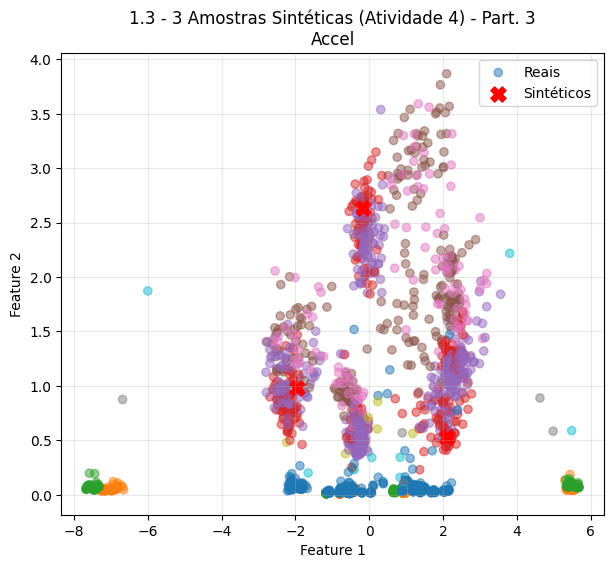


Exibido gráfico das novas amostras sintéticas.


(array([[-1.59766569e-01,  2.62992007e+00,  1.04621574e+01,
         -1.77956418e+01,  6.96891069e+00,  9.76033175e+00,
          2.32021159e+00,  1.53088927e+01,  3.17566096e+00,
          1.00662622e+02, -2.69690833e+00,  2.96513406e+00,
          7.94625860e+00, -2.00511920e+01,  1.60702429e+01,
          2.89235878e-01,  1.20000000e+00,  2.31059205e-01,
          1.40430149e+00,  3.72343489e-01,  6.00000000e-01],
        [-1.96189083e+00,  9.81397511e-01,  1.37881951e+00,
         -4.10405735e+00,  4.81714578e+00,  9.73505358e+00,
          1.11596180e+00,  1.25395736e+01,  7.18004180e+00,
          9.60177478e+01,  1.71410069e+00,  9.91638847e-01,
          4.86206428e+00, -9.24576500e-01,  3.92568021e+00,
          6.00109402e-02,  1.02979437e+00,  5.03697306e-02,
          2.20000000e+00,  6.12415636e-02,  9.10616878e-01],
        [ 2.10460119e+00,  5.35244201e-01,  3.51528517e+00,
          9.56926848e-02,  4.72188818e+00,  9.22747915e+00,
          7.61709207e-01,  1.15064547e

In [15]:
def visualizar_sinteticos_part3(X, y, atividade=4, n_sint=3, titulo=""):
    """
    1.3 - Visualiza 3 amostras sintéticas (apenas participante 3),
    usando apenas as primeiras 2 features num scatter plot.
    """
    novos, novos_labels = aplicar_smote(X, y, atividade, k=5, n_novos=n_sint)

    # Apagar tudo exceto as 2 primeiras features
    X_vis = X[:, :2]
    novos_vis = novos[:, :2]

    # Plot
    plt.figure(figsize=(7, 6))

    # Dados reais
    plt.scatter(X_vis[:, 0], X_vis[:, 1],
                c=y, cmap='tab10', alpha=0.5, label='Reais')

    # Dados sintéticos
    plt.scatter(novos_vis[:, 0], novos_vis[:, 1],
                c='red', marker='X', s=120, label='Sintéticos')

    plt.title(f"1.3 - 3 Amostras Sintéticas (Atividade {atividade}) - Part. 3\n{titulo}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nExibido gráfico das novas amostras sintéticas.")

    return novos, novos_labels

print("\n=== Teste 1.3 ===")
visualizar_sinteticos_part3(X_accel, y_accel, atividade=4, n_sint=3, titulo="Accel")

## 2

### 2.1

In [16]:
import torch

def load_embedding_model():
    print("A carregar modelo HARNet5 (feature encoder)...")
    repo = 'OxWearables/ssl-wearables'
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    encoder = model.feature_extractor
    encoder.eval()
    encoder.to("cpu")
    return encoder

# ---------- Segmentação ACC ----------
def acc_segmentation_for_embeddings(data):
    TIMESTAMP_COL = 10
    MIN_SEGMENT_SIZE = 20
    fs_in_hz = 51.5
    win_size = 5000

    start_time = data[0, TIMESTAMP_COL]
    end_time = start_time + win_size

    activities = []
    segments = []

    while end_time < data[-1, TIMESTAMP_COL]:
        mask = (data[:, TIMESTAMP_COL] >= start_time) & (data[:, TIMESTAMP_COL] < end_time)

        if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):
            acc_xyz = data[mask, 1:4]
            activity = int(data[mask, -1][0])

            segments.append(acc_xyz)
            activities.append(activity)

        start_time = end_time - win_size/2
        end_time = start_time + win_size

    return segments, activities


# ---------- Reamostragem para 30 Hz ----------
def resample_segment_to_30hz(segment, fs_in=51.5):
    win_size = 5
    fs_target = 30.0

    t_in = np.arange(segment.shape[0]) / fs_in
    t_out = np.arange(0, win_size, 1.0 / fs_target)

    res = np.zeros((len(t_out), 3), dtype=np.float32)
    for i in range(3):
        res[:, i] = np.interp(t_out, t_in, segment[:, i])
    return res


# ---------- Criar dataset de embeddings ----------
def create_embeddings_dataset(data):

    encoder = load_embedding_model()

    print("A segmentar ACC...")
    segments, activities = acc_segmentation_for_embeddings(data)

    print(f"Segmentos obtidos: {len(segments)}")

    # Reamostrar cada segmento
    print("A reamostrar para 30 Hz...")
    resampled = [resample_segment_to_30hz(seg) for seg in segments]

    # Preparar tensor para o modelo (N, C, T)
    x_all = np.transpose(np.array(resampled), (0, 2, 1))  # → (N, 3, T)

    embeddings_list = []
    batch_size = 16

    print("A gerar embeddings...")
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            xb = torch.from_numpy(x_all[i:i+batch_size]).float()
            eb = encoder(xb)
            embeddings_list.append(eb.cpu().numpy())

    X_emb = np.concatenate(embeddings_list, axis=0)
    y_emb = np.array(activities)

    print(f"Embedding dataset criado: {X_emb.shape}")
    print(f"Labels: {y_emb.shape}")

    return X_emb, y_emb

## 3

#### 3.1

In [17]:
import numpy as np

# --- INICIALIZAÇÃO CORRETA (DUAS LISTAS SEPARADAS) ---
X_features_list = []
y_features_list = []
subjects_list_feats = []  # <--- Lista de sujeitos para as Features

X_embeddings_list = []
y_embeddings_list = []
subjects_list_embs = []   # <--- Lista de sujeitos para os Embeddings



for part_id in range(0, 15):
    print(f" A processar Participante {part_id}...")
    
    try:
        data = load_participant_data(part_id)
        if len(data) == 0: continue # Salta se vazio
        
        # --- 1. FEATURES MANUAIS ---
        X_feats, y_feats = extract_feature_set(data, vector_type='accel')
        
        # Filtro atividades <= 7
        mask_f = y_feats <= 7
        X_feats = X_feats[mask_f]
        y_feats = y_feats[mask_f]
        
        X_features_list.append(X_feats)
        y_features_list.append(y_feats)
        
        # ACriar sujeitos baseados no tamanho das Features
        subjects_list_feats.append(np.full(len(y_feats), part_id))
        
        # --- 2. EMBEDDINGS ---
        X_emb, y_emb = create_embeddings_dataset(data)
        
        X_embeddings_list.append(X_emb)
        y_embeddings_list.append(y_emb)
        
        # Criar sujeitos baseados no tamanho dos Embeddings
        subjects_list_embs.append(np.full(len(y_emb), part_id))

    except Exception as e:
        print(f" Erro no Participante {part_id}: {e}")



# Para Features
X_features_all = np.concatenate(X_features_list, axis=0)
y_features_all = np.concatenate(y_features_list, axis=0)
subjects_all_feats = np.concatenate(subjects_list_feats, axis=0) # <--- Usar este no 3.2 para Features

# Para Embeddings
X_embeddings_all = np.concatenate(X_embeddings_list, axis=0)
y_embeddings_all = np.concatenate(y_embeddings_list, axis=0)
subjects_all_embs = np.concatenate(subjects_list_embs, axis=0)   # <--- Usar este no 3.2 para Embeddings

print("\n DATASET CARREGADO:")
print(f"   Features:   X={X_features_all.shape}, Sujeitos={subjects_all_feats.shape}")
print(f"   Embeddings: X={X_embeddings_all.shape}, Sujeitos={subjects_all_embs.shape}")



 A processar Participante 0...


A carregar modelo HARNet5 (feature encoder)...


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 351
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (351, 512, 1)
Labels: (351,)
 A processar Participante 1...
A carregar modelo HARNet5 (feature encoder)...


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


...

131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 335
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (335, 512, 1)
Labels: (335,)
 A processar Participante 13...
A carregar modelo HARNet5 (feature encoder)...


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 347
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (347, 512, 1)
Labels: (347,)
 A processar Participante 14...
A carregar modelo HARNet5 (feature encoder)...


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 340
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (340, 512, 1)
Labels: (340,)

 DATASET CARREGADO:
   Features:   X=(27628, 21), Sujeitos=(27628,)
   Embeddings: X=(5130, 512, 1), Sujeitos=(5130,)


### 3.2

In [18]:
def split_between_subjects(X, y, subjects, random_state=42):
    # 1. Identificar participantes únicos presentes nos dados
    unique_subs = np.unique(subjects)
    n_subs = len(unique_subs)
    
    # Misturar a ordem dos participantes
    np.random.seed(random_state)
    shuffled_subs = np.random.permutation(unique_subs)
    
    # 2. Definir os grupos (Treino=9, Val=3, Teste=Resto)
    # Ajustamos para o caso de haver menos de 15 participantes
    n_train = 9
    n_val = 3
    
    if n_subs < (n_train + n_val):
        print(f" Aviso: Só existem {n_subs} participantes. Ajustando divisão...")
        n_train = int(n_subs * 0.6)
        n_val = int(n_subs * 0.2)
    
    train_subs = shuffled_subs[:n_train]
    val_subs = shuffled_subs[n_train : n_train + n_val]
    test_subs = shuffled_subs[n_train + n_val :]
    
    print(f"  > Participantes ({n_subs} total)")
    print(f"  > Treino ({len(train_subs)}): {train_subs}")
    print(f"  > Valid  ({len(val_subs)}): {val_subs}")
    print(f"  > Teste  ({len(test_subs)}): {test_subs}")
    
    # 3. Criar máscaras e filtrar
    mask_train = np.isin(subjects, train_subs)
    mask_val   = np.isin(subjects, val_subs)
    mask_test  = np.isin(subjects, test_subs)
    
    return X[mask_train], y[mask_train], X[mask_val], y[mask_val], X[mask_test], y[mask_test]

# --- EXECUÇÃO ---
print(" A executar Split 3.2 (Between-Subjects)...")

# A) FEATURES MANUAIS
print("\n--- A. FEATURES DATASET ---")
if 'subjects_all_feats' in locals():
    Xf_train_b, yf_train_b, Xf_val_b, yf_val_b, Xf_test_b, yf_test_b = split_between_subjects(
        X_features_all, y_features_all, subjects_all_feats
    )
    print(f" Features: Treino={len(yf_train_b)}, Val={len(yf_val_b)}, Teste={len(yf_test_b)}")
else:
    print(" Erro: 'subjects_all_feats' não encontrado. Corre a célula de carregamento anterior!")

# B) EMBEDDINGS
print("\n--- B. EMBEDDINGS DATASET ---")
if 'subjects_all_embs' in locals():
    Xe_train_b, ye_train_b, Xe_val_b, ye_val_b, Xe_test_b, ye_test_b = split_between_subjects(
        X_embeddings_all, y_embeddings_all, subjects_all_embs
    )
    print(f" Embeddings: Treino={len(ye_train_b)}, Val={len(ye_val_b)}, Teste={len(ye_test_b)}")
else:
    print(" Erro: 'subjects_all_embs' não encontrado.")

 A executar Split 3.2 (Between-Subjects)...

--- A. FEATURES DATASET ---
  > Participantes (15 total)
  > Treino (9): [ 9 11  0 13  5  8  2  1 14]
  > Valid  (3): [ 4  7 10]
  > Teste  (3): [12  3  6]
 Features: Treino=16586, Val=5410, Teste=5632

--- B. EMBEDDINGS DATASET ---
  > Participantes (15 total)
  > Treino (9): [ 9 11  0 13  5  8  2  1 14]
  > Valid  (3): [ 4  7 10]
  > Teste  (3): [12  3  6]
 Embeddings: Treino=3378, Val=734, Teste=1018


### 3.4

In [ ]:
from sklearn.preprocessing import StandardScaler

def preparar_cenarios(X_train, X_val, X_test, y_train, nome_dataset="Dados"):
    """
    Gera os 3 cenários pedidos: All, PCA(90%), ReliefF(Top15).
    Aplica fit no train e transform em todos.
    """
    print(f"\n A processar cenários para: {nome_dataset}...")

    if X_train.ndim > 2:
        print(f" Detetado formato 3D {X_train.shape}. A converter para 2D...")
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_val = X_val.reshape(X_val.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)

    
    dic_cenarios = {}
    
    # 1. NORMALIZAÇÃO (Obrigatório antes de PCA/KNN) 
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train) # Fit só no treino!
    X_val_sc = scaler.transform(X_val)
    X_te_sc = scaler.transform(X_test)
    
    # --- CENÁRIO A: ALL FEATURES (Normalizadas) --- [cite: 47]
    dic_cenarios['All'] = (X_tr_sc, X_val_sc, X_te_sc)
    
    # --- PCA (90%) --- 
    pca = PCA(n_components=0.90)
    X_tr_pca = pca.fit_transform(X_tr_sc) # Fit só no treino!
    X_val_pca = pca.transform(X_val_sc)
    X_te_pca = pca.transform(X_te_sc)
    
    dic_cenarios['PCA'] = (X_tr_pca, X_val_pca, X_te_pca)
    print(f"   > PCA: Reduziu de {X_tr_sc.shape[1]} para {X_tr_pca.shape[1]} componentes.")
    
    # --- CENÁRIO C: ReliefF (Top 15) --- 
    # Calcular índices apenas com base no treino
    print("   > A calcular ReliefF (pode demorar um pouco)...")
    top_idx, _ = selecionar_melhores_features(X_tr_sc, y_train, metodo='relieff', top_n=15)
    
    X_tr_rel = X_tr_sc[:, top_idx]
    X_val_rel = X_val_sc[:, top_idx]
    X_te_rel = X_te_sc[:, top_idx]
    
    dic_cenarios['ReliefF'] = (X_tr_rel, X_val_rel, X_te_rel)
    print(f"   > ReliefF: Selecionadas {X_tr_rel.shape[1]} features.")
    
    return dic_cenarios

if 'Xf_train_b' in locals() and 'Xe_train_b' in locals():
    
    # 1. Cenários para FEATURES MANUAIS (Between-Subjects)
    cenarios_feat_between = preparar_cenarios(
        Xf_train_b, Xf_val_b, Xf_test_b, yf_train_b, "Features (Between-Subj)"
    )
    
    # 2. Cenários para EMBEDDINGS (Between-Subjects)
    cenarios_emb_between = preparar_cenarios(
        Xe_train_b, Xe_val_b, Xe_test_b, ye_train_b, "Embeddings (Between-Subj)"
    )
    
    print("\n Ponto 3.4 Concluído! Os dados estão prontos para treinar o classificador.")
    print("Variáveis criadas: 'cenarios_feat_between' e 'cenarios_emb_between'")
    
else:
    print(" ERRO: Faltam as variáveis do Split 3.2 (Xf_train_b, etc).")
    print(" Tens de correr a célula do Ponto 3.2 (Between-Subjects) antes desta.")


 A processar cenários para: Features (Between-Subj)...
   > PCA: Reduziu de 21 para 7 componentes.
   > A calcular ReliefF (pode demorar um pouco)...

4.6 - Top 15 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   0  |  Score = 357.53322
 2. Feature   8  |  Score = 248.38182
 3. Feature   5  |  Score = 205.76031
 4. Feature   9  |  Score = 203.73207
 5. Feature   4  |  Score = 192.56259
 6. Feature   7  |  Score = 182.23193
 7. Feature  10  |  Score = 181.89437
 8. Feature   6  |  Score = 163.27996
 9. Feature  14  |  Score = 141.65906
10. Feature   2  |  Score = 113.73290
11. Feature   3  |  Score = 101.31445
12. Feature  13  |  Score = 99.66906
13. Feature  17  |  Score = 96.29568
14. Feature  12  |  Score = 74.32042
15. Feature   1  |  Score = 73.90524

   > ReliefF: Selecionadas 15 features.

 A processar cenários para: Embeddings (Between-Subj)...
 Detetado formato 3D (3378, 512, 1). A converter para 2D...
   >

## 4

### 4.1

In [30]:
import numpy as np
from collections import Counter

# ==============================================================================
# 4.1 - Implementação Manual do k-NN (Sem sklearn)
# ==============================================================================

class KNNManual:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Guardar os dados de treino (Lazy Learning).
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        print(f" Modelo treinado! Dados guardados: {self.X_train.shape}")

    def predict(self, X_test):
        """
        Calcula distâncias e prevê a classe para cada ponto de teste.
        """
        X_test = np.array(X_test)
        predictions = []
        
        print(f" INÍCIO: A classificar {len(X_test)} amostras...")
        
        # Loop por cada amostra de teste
        for i, x_novo in enumerate(X_test):
            
            # --- IMPRIMIR PROGRESSO (Força a escrita com flush=True) ---
            # Imprime a cada 10 amostras para veres o texto a correr
            if i % 10 == 0:
                print(f"   > A processar amostra {i}/{len(X_test)}...", end='\r', flush=True)
            
            # 1. Calcular Distância Euclidiana para TODOS os pontos de treino
            # (Vetorização: faz o cálculo para as 18.000 linhas de treino de uma vez)
            diferencas = self.X_train - x_novo
            quadrados = diferencas ** 2
            soma_quadrados = np.sum(quadrados, axis=1) # Soma x^2 + y^2 + z^2
            distancias = np.sqrt(soma_quadrados)
            
            # 2. Encontrar os vizinhos mais próximos
            # argsort devolve os Índices ordenados da menor distância para a maior
            k_indices = np.argsort(distancias)[:self.k]
            
            # 3. Ver quais são as classes desses vizinhos
            k_vizinhos_labels = self.y_train[k_indices]
            
            # 4. Votação (Moda)
            # Ex: [1, 1, 1, 2, 5] -> O 1 ganha com 3 votos
            votos = Counter(k_vizinhos_labels)
            classe_vencedora = votos.most_common(1)[0][0]
            
            predictions.append(classe_vencedora)
            
        print(f"\n FIM: {len(predictions)} previsões concluídas.")
        return np.array(predictions)

### 4.2

--- 4.1 Treino ---
 Modelo treinado! Dados guardados: (16586, 21)

--- 4.1 Classificação ---
 INÍCIO: A classificar 50 amostras...
   > A processar amostra 40/50...
 FIM: 50 previsões concluídas.

--- 4.2 Avaliação ---
 Accuracy: 36.0% (18/50 corretos)


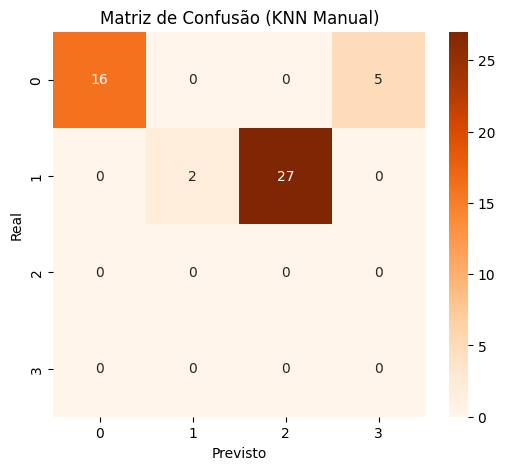

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Escolher os dados (Usamos as Features do Split Between-Subjects que fizeste no 3.2)
if 'Xf_train_b' in locals():
    # Vamos usar apenas 50 amostras de teste para ser rápido
    # (Podes aumentar para 200 ou mais se tiveres paciência)
    n_teste = 50
    X_teste_pequeno = Xf_test_b[:n_teste]
    y_teste_pequeno = yf_test_b[:n_teste]

    # 2. Criar e Treinar o TEU modelo
    print("--- 4.1 Treino ---")
    meu_knn = KNNManual(k=5)
    meu_knn.fit(Xf_train_b, yf_train_b)

    # 3. Fazer Previsões (Isto vai usar o teu loop com prints)
    print("\n--- 4.1 Classificação ---")
    y_pred_manual = meu_knn.predict(X_teste_pequeno)

    # 4. Avaliação (Ponto 4.2)
    acc = accuracy_score(y_teste_pequeno, y_pred_manual)
    print(f"\n--- 4.2 Avaliação ---")
    print(f" Accuracy: {acc:.1%} ({np.sum(y_teste_pequeno == y_pred_manual)}/{n_teste} corretos)")

    # Matriz de Confusão
    cm = confusion_matrix(y_teste_pequeno, y_pred_manual)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.title('Matriz de Confusão (KNN Manual)')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()
    
else:
    print(" Erro: Não tens os dados de treino (Xf_train_b) na memória. Corre o passo 3.2!")

🚀 A testar k-NN Manual com DADOS NORMALIZADOS (Ponto 3.4)...
--- 4.1 Treino (Dados Normalizados) ---
 Modelo treinado! Dados guardados: (16586, 21)

--- 4.1 Classificação ---
 INÍCIO: A classificar 50 amostras...
   > A processar amostra 40/50...
 FIM: 50 previsões concluídas.

--- 4.2 Avaliação ---
🎯 Accuracy: 66.0% (33/50 corretos)


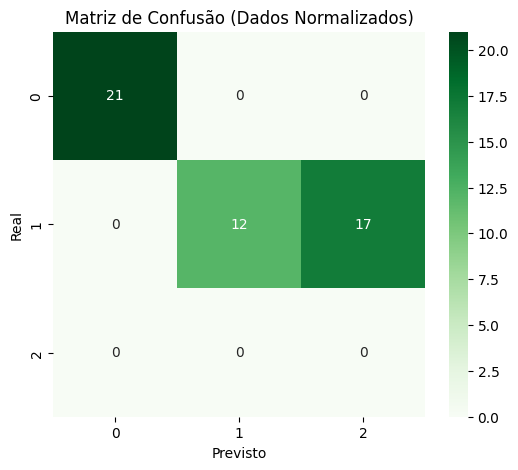